# **Importing**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

from sklearn.preprocessing import StandardScaler,RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report,accuracy_score,f1_score,recall_score,roc_curve,make_scorer
from sklearn.metrics import confusion_matrix,RocCurveDisplay,auc
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [3]:
df = pd.read_csv('SBAnational.csv', low_memory=False)
df_copy = df.copy()


**1.Inspection**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 899164 entries, 0 to 899163
Data columns (total 27 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   LoanNr_ChkDgt      899164 non-null  int64  
 1   Name               899150 non-null  object 
 2   City               899134 non-null  object 
 3   State              899150 non-null  object 
 4   Zip                899164 non-null  int64  
 5   Bank               897605 non-null  object 
 6   BankState          897598 non-null  object 
 7   NAICS              899164 non-null  int64  
 8   ApprovalDate       899164 non-null  object 
 9   ApprovalFY         899164 non-null  object 
 10  Term               899164 non-null  int64  
 11  NoEmp              899164 non-null  int64  
 12  NewExist           899028 non-null  float64
 13  CreateJob          899164 non-null  int64  
 14  RetainedJob        899164 non-null  int64  
 15  FranchiseCode      899164 non-null  int64  
 16  Ur

In [6]:
def report(df):
    # Dictionary mapping column names to their descriptions
    descriptions = {
        'LoanNr_ChkDgt': 'Identifier Primary key',
        'Name': 'Borrower name',
        'City': 'Borrower city',
        'State': 'Borrower state',
        'Zip': 'Borrower zip code',
        'Bank': 'Bank name',
        'BankState': 'Bank state',
        'NAICS': 'North American industry classification system code',
        'ApprovalDate': 'Date SBA commitment issued',
        'ApprovalFY': 'Fiscal year of commitment',
        'Term': 'Loan term in months',
        'NoEmp': 'Number of business employees',
        'NewExist': '1 = Existing business, 2 = New business',
        'CreateJob': 'Number of jobs created',
        'RetainedJob': 'Number of jobs retained',
        'FranchiseCode': 'Franchise code, (00000 or 00001) = No franchise',
        'UrbanRural': '1 = Urban, 2 = rural, 0 = undefined',
        'RevLineCr': 'Revolving line of credit: Y = Yes, N = No',
        'LowDoc': 'LowDoc Loan Program: Y = Yes, N = No',
        'ChgOffDate': 'The date when a loan is declared to be in default',
        'DisbursementDate': 'Disbursement date',
        'DisbursementGross': 'Amount disbursed',
        'BalanceGross': 'Gross amount outstanding',
        'MIS_Status': 'Loan status charged off = CHGOFF, Paid in full = PIF',
        'ChgOffPrinGr': 'Charged-off amount',
        'GrAppv': 'Gross amount of loan approved by bank',
        'SBA_Appv': 'SBA’s guaranteed amount of approved loan'
    }

    col = []
    d_type = []
    uniques = []
    n_uniques = []
    nan = []
    desc = []

    for i in df.columns:
        col.append(i)
        d_type.append(df[i].dtypes)
        uniques.append(df[i].unique()[:5])
        n_uniques.append(df[i].nunique())
        nan.append(df[i].isna().sum() / len(df) * 100)
        desc.append(descriptions.get(i, 'No description available'))  # Add description or fallback to default

    return pd.DataFrame({
        'Column': col,
        'd_type': d_type,
        'unique_sample': uniques,
        'n_uniques': n_uniques,
        'nan%': nan,
        'Description': desc
    })

# Call the report function with the dataframe
report(df)


,Column,d_type,unique_sample,n_uniques,nan%,Description
0,LoanNr_ChkDgt,int64,"[1000014003, 1000024006, 1000034009, 100004400...",899164,0.000000,Identifier Primary key
1,Name,object,"[ABC HOBBYCRAFT, LANDMARK BAR & GRILLE (THE), ...",779583,0.001557,Borrower name
2,City,object,"[EVANSVILLE, NEW PARIS, BLOOMINGTON, BROKEN AR...",32581,0.003336,Borrower city
3,State,object,"[IN, OK, FL, CT, NJ]",51,0.001557,Borrower state
4,Zip,int64,"[47711, 46526, 47401, 74012, 32801]",33611,0.000000,Borrower zip code
5,Bank,object,"[FIFTH THIRD BANK, 1ST SOURCE BANK, GRANT COUN...",5802,0.173383,Bank name
6,BankState,object,"[OH, IN, OK, FL, DE]",56,0.174162,Bank state
7,NAICS,int64,"[451120, 722410, 621210, 0, 332721]",1312,0.000000,North American industry classification system ...
8,ApprovalDate,object,"[28-Feb-97, 2-Jun-80, 7-Feb-06, 11-Jun-80, 4-O...",9859,0.000000,Date SBA commitment issued
9,ApprovalFY,object,"[1997, 1980, 2006, 1998, 1999]",52,0.000000,Fiscal year of commitment


In [7]:
df.isnull().sum()


LoanNr_ChkDgt             0
Name                     14
City                     30
State                    14
Zip                       0
Bank                   1559
BankState              1566
NAICS                     0
ApprovalDate              0
ApprovalFY                0
Term                      0
NoEmp                     0
NewExist                136
CreateJob                 0
RetainedJob               0
FranchiseCode             0
UrbanRural                0
RevLineCr              4528
LowDoc                 2582
ChgOffDate           736465
DisbursementDate       2368
DisbursementGross         0
BalanceGross              0
MIS_Status             1997
ChgOffPrinGr              0
GrAppv                    0
SBA_Appv                  0
dtype: int64

**2.Pre-Processing for EDA**

In [10]:
df.drop(columns=['ChgOffDate'], inplace=True)

In [11]:
df[['DisbursementGross', 'BalanceGross', 'ChgOffPrinGr', 'GrAppv', 'SBA_Appv']].head()


,DisbursementGross,BalanceGross,ChgOffPrinGr,GrAppv,SBA_Appv
0,"$60,000.00",$0.00,$0.00,"$60,000.00","$48,000.00"
1,"$40,000.00",$0.00,$0.00,"$40,000.00","$32,000.00"
2,"$287,000.00",$0.00,$0.00,"$287,000.00","$215,250.00"
3,"$35,000.00",$0.00,$0.00,"$35,000.00","$28,000.00"
4,"$229,000.00",$0.00,$0.00,"$229,000.00","$229,000.00"


because of the dollar sign $

In [13]:

df['DisbursementGross'] = df['DisbursementGross'].map(lambda x: str(x).replace('$', '').replace(',', '') if isinstance(x, str) else x)
df['BalanceGross'] = df['BalanceGross'].map(lambda x: str(x).replace('$', '').replace(',', '') if isinstance(x, str) else x)
df['ChgOffPrinGr'] = df['ChgOffPrinGr'].map(lambda x: str(x).replace('$', '').replace(',', '') if isinstance(x, str) else x)
df['GrAppv'] = df['GrAppv'].map(lambda x: str(x).replace('$', '').replace(',', '') if isinstance(x, str) else x)
df['SBA_Appv'] = df['SBA_Appv'].map(lambda x: str(x).replace('$', '').replace(',', '') if isinstance(x, str) else x)

df[['DisbursementGross', 'BalanceGross', 'ChgOffPrinGr', 'GrAppv', 'SBA_Appv']] = \
df[['DisbursementGross', 'BalanceGross', 'ChgOffPrinGr', 'GrAppv', 'SBA_Appv']].apply(pd.to_numeric)


In [14]:
df[['DisbursementGross', 'BalanceGross', 'ChgOffPrinGr', 'GrAppv', 'SBA_Appv']].head()


,DisbursementGross,BalanceGross,ChgOffPrinGr,GrAppv,SBA_Appv
0,60000.0,0.0,0.0,60000.0,48000.0
1,40000.0,0.0,0.0,40000.0,32000.0
2,287000.0,0.0,0.0,287000.0,215250.0
3,35000.0,0.0,0.0,35000.0,28000.0
4,229000.0,0.0,0.0,229000.0,229000.0


In [15]:
# Create a new column with the industry the NAICS code represents
# Selects only the first two numbers of the NAICS code
df['Industry'] = df['NAICS'].astype('str').apply(lambda x: x[:2])

# Maps the approprate industry to each record based on the first two digits of the NAICS code
df['Industry'] = df['Industry'].map({
    '11': 'Ag/For/Fish/Hunt',
    '21': 'Min/Quar/Oil_Gas_ext',
    '22': 'Utilities',
    '23': 'Construction',
    '31': 'Manufacturing',
    '32': 'Manufacturing',
    '33': 'Manufacturing',
    '42': 'Wholesale_trade',
    '44': 'Retail_trade',
    '45': 'Retail_trade',
    '48': 'Trans/Ware',
    '49': 'Trans/Ware',
    '51': 'Information',
    '52': 'Finance/Insurance',
    '53': 'RE/Rental/Lease',
    '54': 'Prof/Science/Tech',
    '55': 'Mgmt_comp',
    '56': 'Admin_sup/Waste_Mgmt_Rem',
    '61': 'Educational',
    '62': 'Healthcare/Social_assist',
    '71': 'Arts/Entertain/Rec',
    '72': 'Accom/Food_serv',
    '81': 'Other_no_pub',
    '92': 'Public_Admin'
})

# Remove records where Industry is NaN (NAICS code was a 0)
df.dropna(subset=['MIS_Status', 'LowDoc', 'Industry'], inplace=True)

# Data type conversions
df['DisbursementDate'] = pd.to_datetime(df['DisbursementDate'], format='%m/%d/%Y', errors='coerce')
df['ApprovalFY'] = pd.to_numeric(df['ApprovalFY'], errors='coerce')


In [16]:
df.nunique()

LoanNr_ChkDgt        692922
Name                 608767
City                  28772
State                    51
Zip                   30516
Bank                   5222
BankState                55
NAICS                  1310
ApprovalDate           7363
ApprovalFY               29
Term                    378
NoEmp                   500
NewExist                  3
CreateJob               218
RetainedJob             322
FranchiseCode          2288
UrbanRural                3
RevLineCr                14
LowDoc                    8
DisbursementDate          0
DisbursementGross    111327
BalanceGross             15
MIS_Status                2
ChgOffPrinGr          73504
GrAppv                17033
SBA_Appv              28473
Industry                 20
dtype: int64

High cardinality features (features with no unique values that needs to be dropped) = [
    'LoanNr_ChkDgt',
    'Name',
    'City',
    'Zip',
    'Bank',
    'NAICS',
    'ApprovalDate',
    'Term',
    'NoEmp',
    'CreateJob',
    'RetainedJob',
    'FranchiseCode',
    'DisbursementDate',
    'DisbursementGross',
    'ChgOffPrinGr',
    'GrAppv',
    'SBA_Appv'
]

**2.EDA**

In [19]:
df.describe(include=['object', 'float', 'int'])


,LoanNr_ChkDgt,Name,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,ApprovalFY,...,UrbanRural,RevLineCr,LowDoc,DisbursementGross,BalanceGross,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv,Industry
count,6.929220e+05,692911,692922,692914,692922.000000,692300,692297,692922.000000,692922,692922.000000,...,692922.000000,690587,692922,6.929220e+05,692922.000000,692922,6.929220e+05,6.929220e+05,6.929220e+05,692922
unique,NaN,608767,28772,51,NaN,5222,55,NaN,7363,NaN,...,NaN,14,8,NaN,NaN,2,NaN,NaN,NaN,20
top,NaN,SUBWAY,LOS ANGELES,CA,NaN,BANK OF AMERICA NATL ASSOC,CA,NaN,30-Jan-04,NaN,...,NaN,N,N,NaN,NaN,P I F,NaN,NaN,NaN,Retail_trade
freq,NaN,913,9731,101637,NaN,74994,94371,NaN,1028,NaN,...,NaN,268158,623207,NaN,NaN,553161,NaN,NaN,NaN,126615
mean,4.667013e+09,NaN,NaN,NaN,53329.321983,NaN,NaN,514143.726411,NaN,2002.994403,...,0.937600,NaN,NaN,1.947953e+05,3.879102,NaN,1.464649e+04,1.831311e+05,1.405350e+05,NaN
std,2.464693e+09,NaN,NaN,NaN,31344.556554,NaN,NaN,173409.423726,NaN,4.947124,...,0.591183,NaN,NaN,2.970694e+05,1642.824216,NaN,6.798720e+04,2.906451e+05,2.376297e+05,NaN
min,1.000014e+09,NaN,NaN,NaN,0.000000,NaN,NaN,111110.000000,NaN,1984.000000,...,0.000000,NaN,NaN,4.000000e+03,0.000000,NaN,0.000000e+00,1.000000e+03,5.000000e+02,NaN
25%,2.539845e+09,NaN,NaN,NaN,25526.000000,NaN,NaN,423430.000000,NaN,2001.000000,...,1.000000,NaN,NaN,3.650000e+04,0.000000,NaN,0.000000e+00,3.000000e+04,1.700000e+04,NaN
50%,4.319169e+09,NaN,NaN,NaN,55112.000000,NaN,NaN,512110.000000,NaN,2004.000000,...,1.000000,NaN,NaN,9.000000e+04,0.000000,NaN,0.000000e+00,7.500000e+04,5.000000e+04,NaN
75%,6.647239e+09,NaN,NaN,NaN,83814.000000,NaN,NaN,621399.000000,NaN,2006.000000,...,1.000000,NaN,NaN,2.170125e+05,0.000000,NaN,0.000000e+00,2.000000e+05,1.500000e+05,NaN


In [20]:
df.shape

(692922, 27)

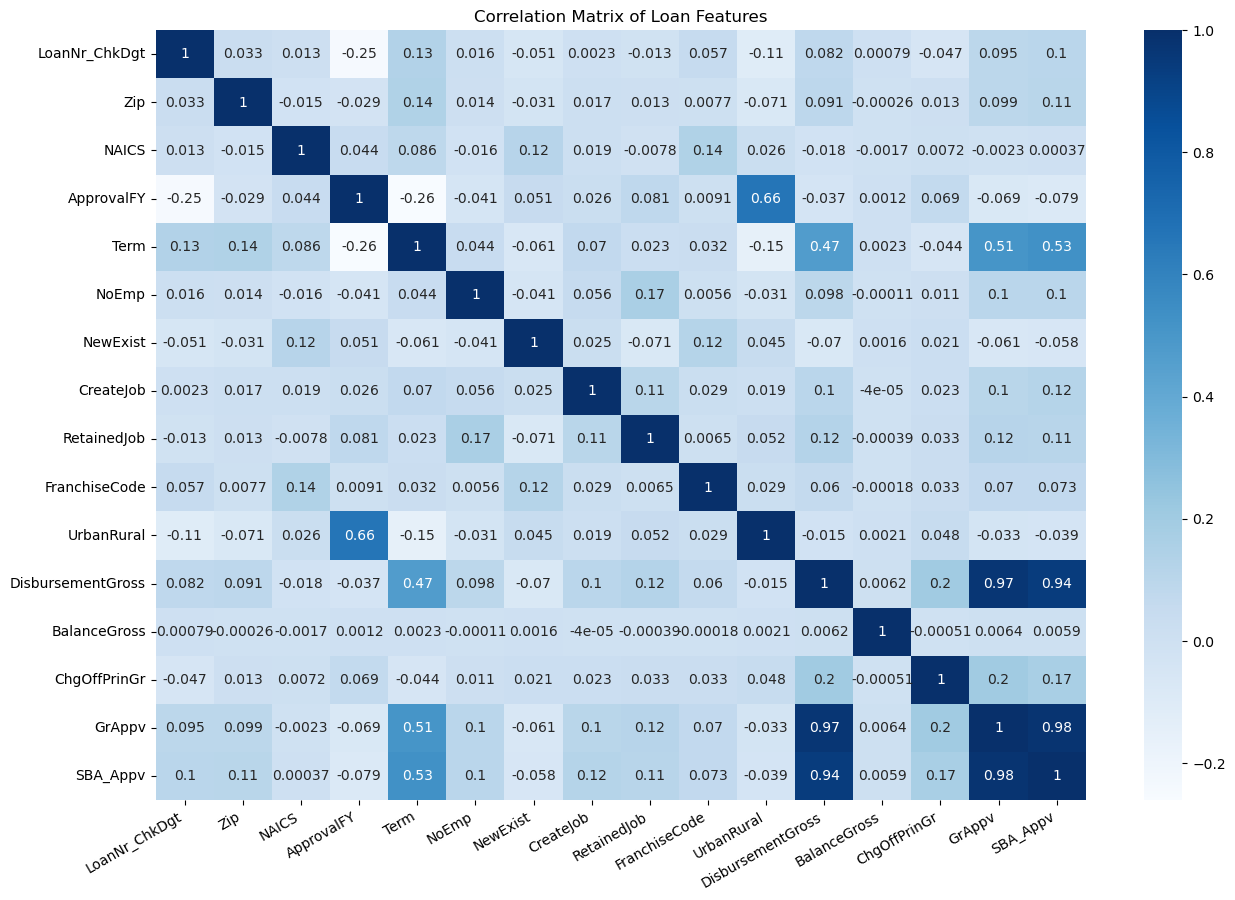

In [21]:
# Select numeric columns only
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Compute the correlation matrix
corr_matrix = df[numeric_cols].corr()

# Plot the heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, cmap='Blues')
plt.title('Correlation Matrix of Loan Features')
plt.xticks(rotation=30, horizontalalignment='right')
plt.yticks(rotation=0)
plt.show()

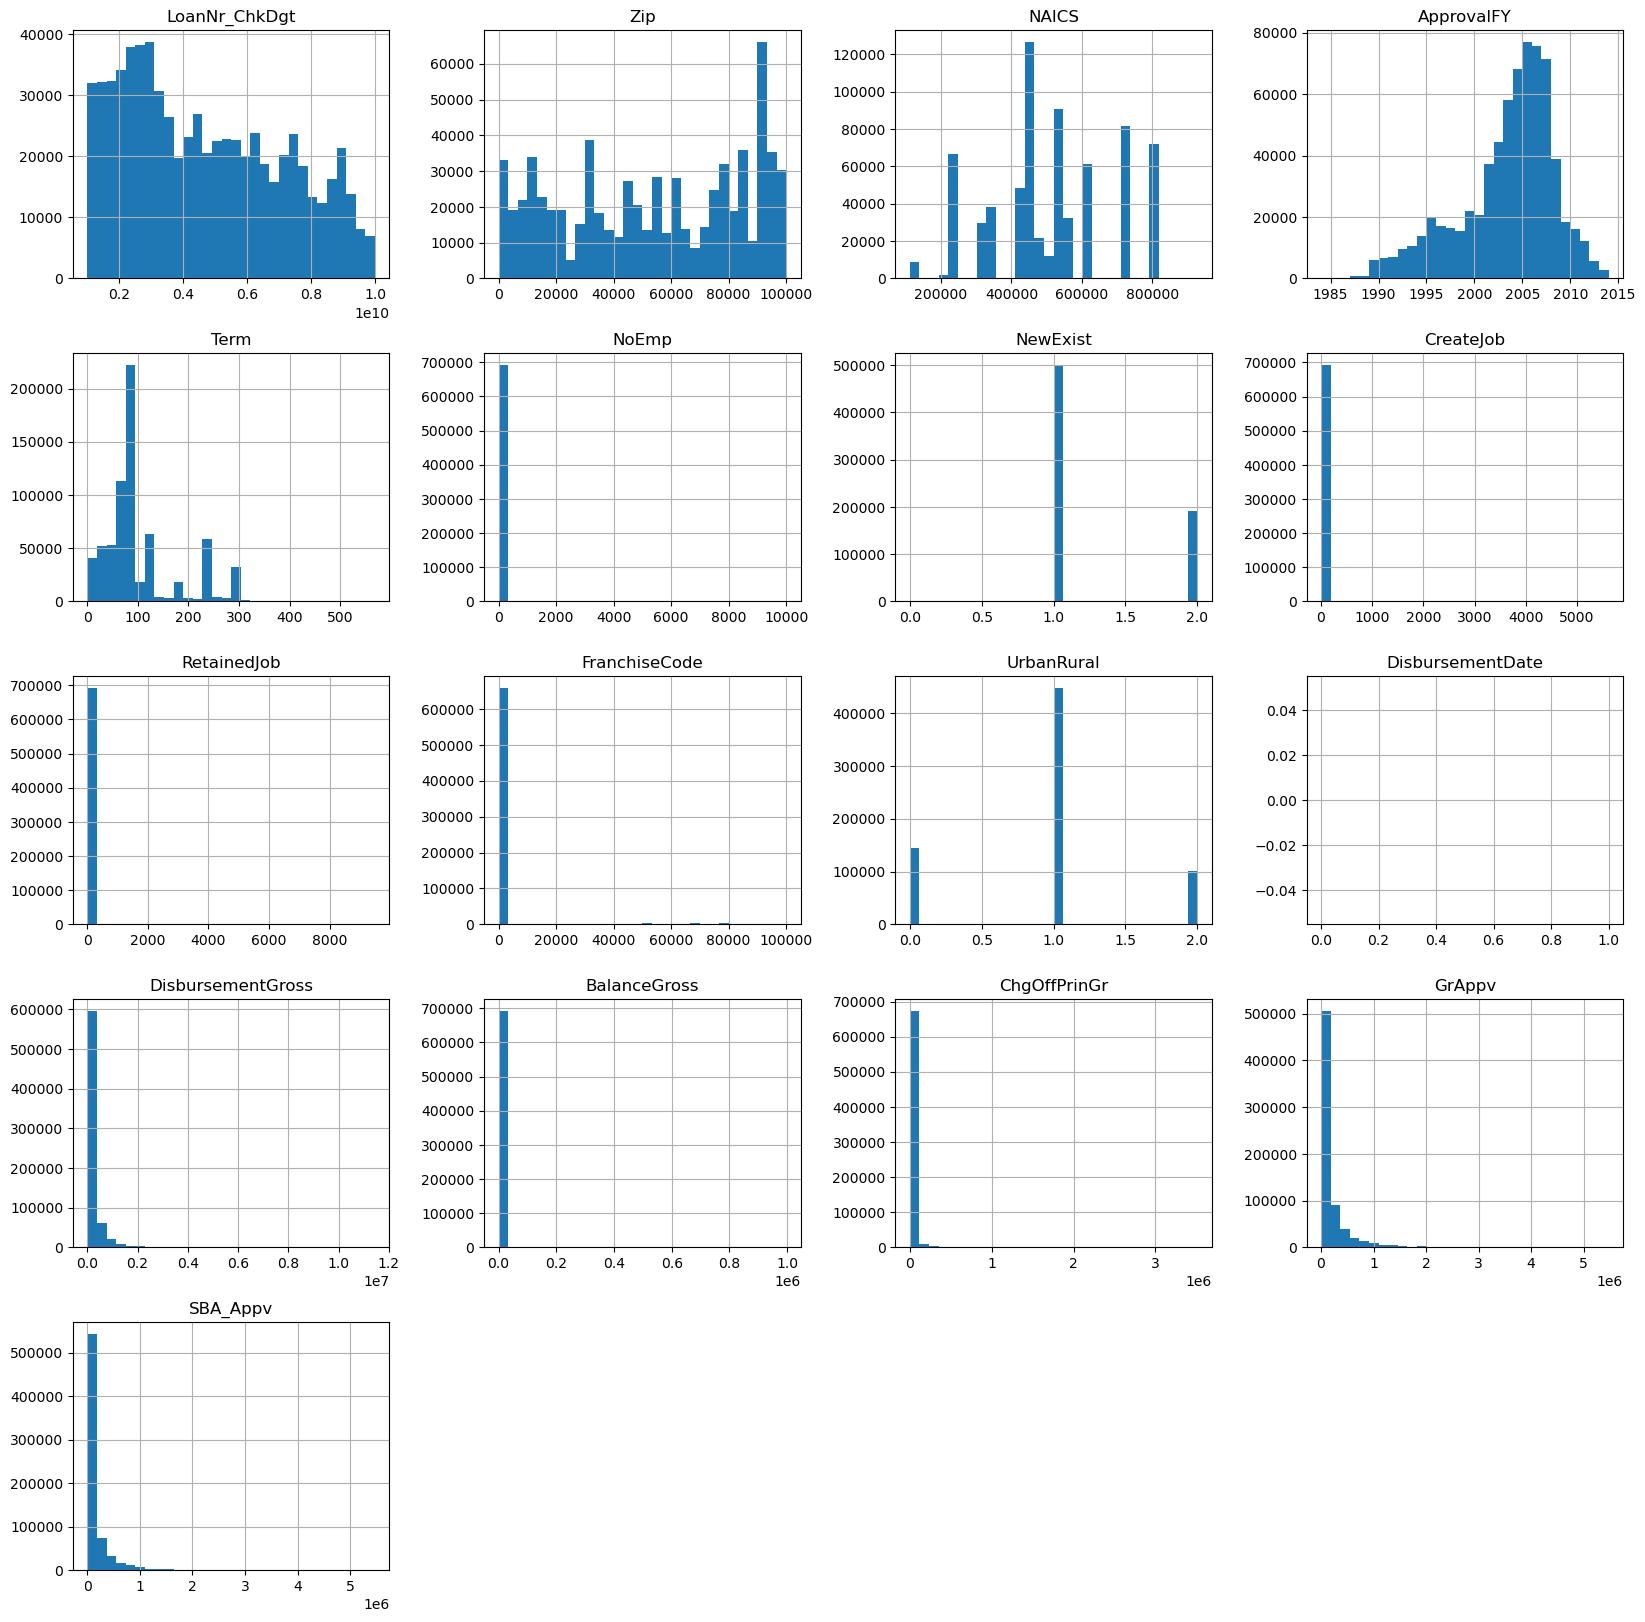

In [22]:
df.hist(bins=30, figsize=(20, 20))
plt.show()

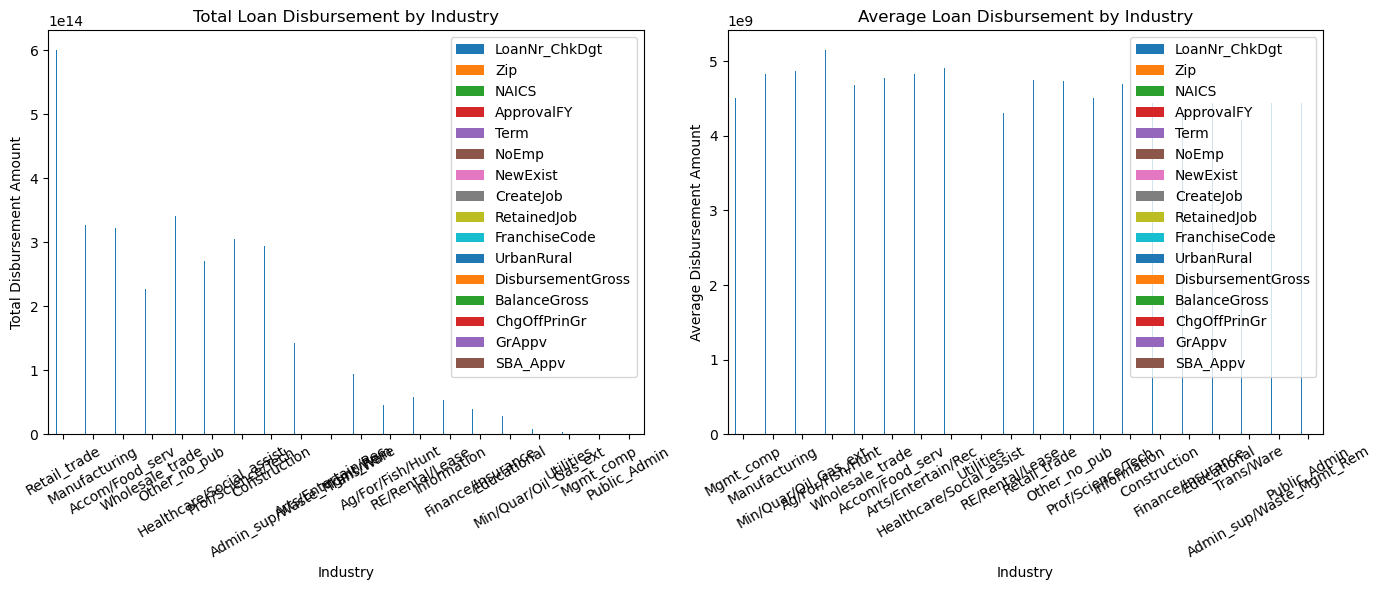

In [23]:
# Group by 'Industry'
industry_group = df.groupby('Industry')

# Aggregate (sum and mean)
df_industrySum = industry_group.sum(numeric_only=True).sort_values('DisbursementGross', ascending=False)
df_industryAve = industry_group.mean(numeric_only=True).sort_values('DisbursementGross', ascending=False)

# Plotting without manually setting tick labels
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# First plot with rotation directly in the plot
df_industrySum.plot(kind='bar', ax=ax1)
ax1.set_title("Total Loan Disbursement by Industry")
ax1.set_xlabel("Industry")
ax1.set_ylabel("Total Disbursement Amount")
ax1.tick_params(axis='x', rotation=30)

# Second plot with rotation directly in the plot
df_industryAve.plot(kind='bar', ax=ax2)
ax2.set_title("Average Loan Disbursement by Industry")
ax2.set_xlabel("Industry")
ax2.set_ylabel("Average Disbursement Amount")
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

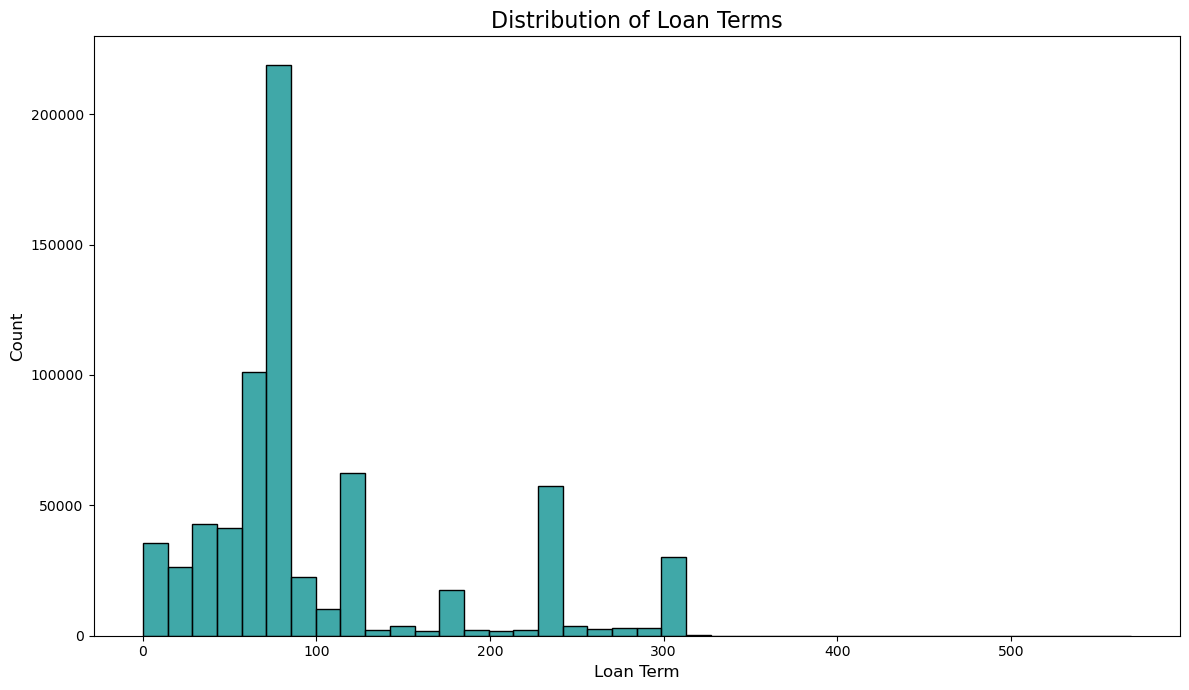

In [24]:
fig, ax = plt.subplots(figsize=(12, 7))
sns.histplot(df['Term'], bins=40, kde=False, color='darkcyan', ax=ax)
ax.set_title('Distribution of Loan Terms', fontsize=16)
ax.set_xlabel('Loan Term', fontsize=12)
ax.set_ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()


The distribution of loan terms isn't quite normal, so we might want to consider scaling it later. There seems to be popular loan terms around the 100, 250 and 300 month marks.



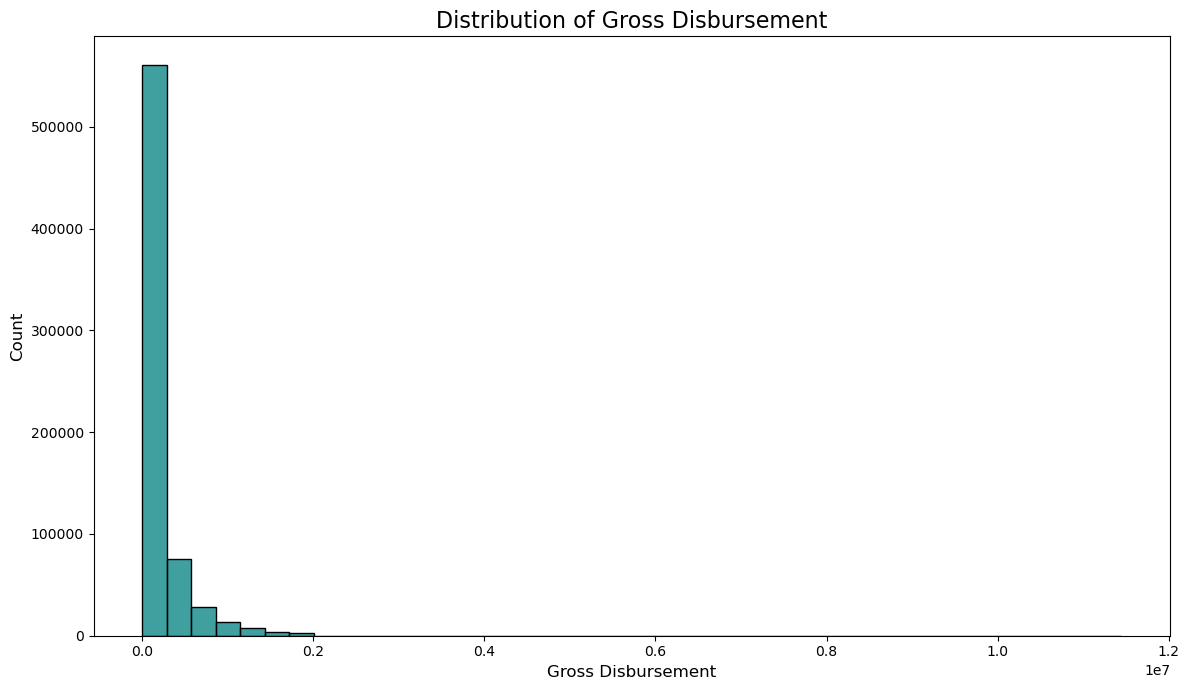

In [26]:

fig, ax = plt.subplots(figsize=(12, 7))
sns.histplot(df['DisbursementGross'], kde=False, bins=40, color='teal', ax=ax)
ax.set_title('Distribution of Gross Disbursement', fontsize=16)
ax.set_xlabel('Gross Disbursement', fontsize=12)
ax.set_ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()


The distibution is not normal, so we'll fix that by logarithmic scaling before we build our model. SBA_Appv and GrAppv are almost perfectly correlated with DisbursementGross, so I'll assume those are also skewed and will take the log of those too.

Let's see if there are any trends over time for the percentage of loans paid in full.

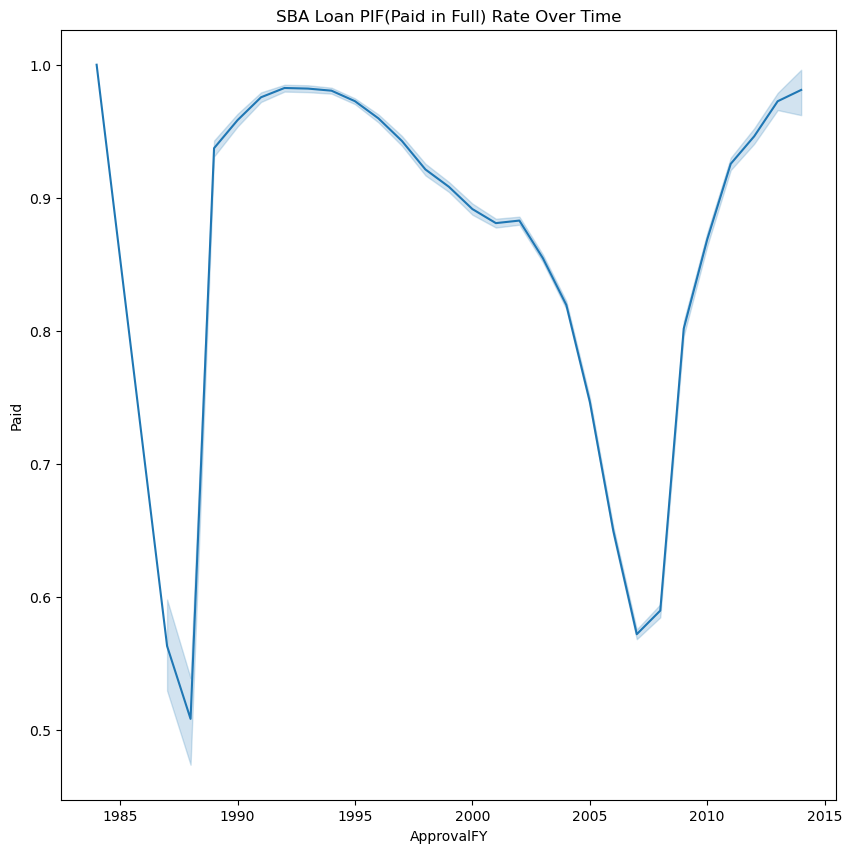

In [28]:
df['Paid'] = df['MIS_Status'].replace({'P I F':'1','CHGOFF':'0'}, regex=True)
df['Paid'] = df['Paid'].astype(float)

fig = plt.figure(figsize=(10,10))
sns.lineplot(x="ApprovalFY", y="Paid", data=df)
plt.title('SBA Loan PIF(Paid in Full) Rate Over Time')
plt.show()


We can see periods where the success rate of loans were very high, specifically 1990-2005 and 2010-2014. We can also see dips in success rate during historical recessions like 2008 and the mid 1980's.

The extremely low success rate of loans before 1985 may be attributed to the small sample size of loans during that period. If we look at a histogram of the amount of loans durting that period, we'll see that very few SBA loans were taken until about 1990.

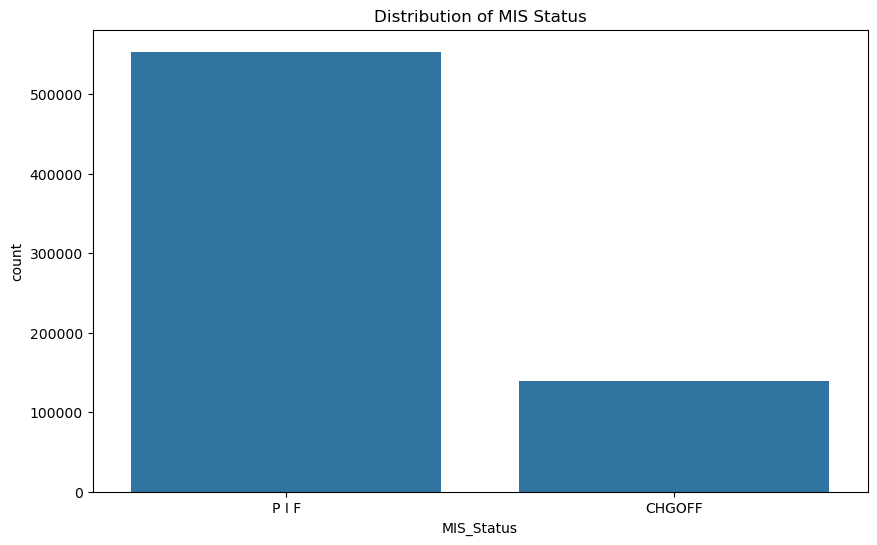

In [37]:
# Categorical columns distribution
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='MIS_Status')
plt.title('Distribution of MIS Status')
plt.show()

### **Plot the relation between non-high cardinality features and the target**

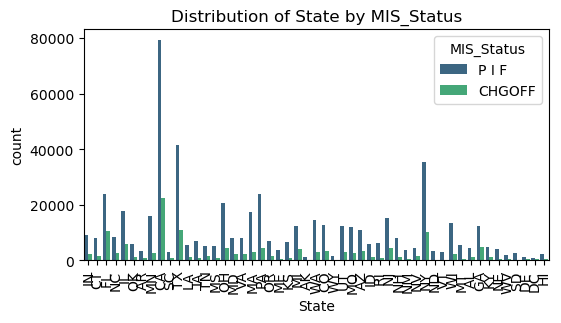

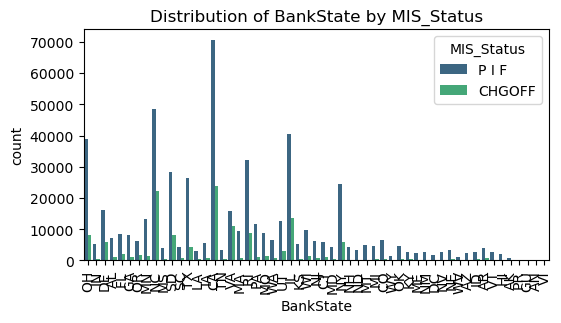

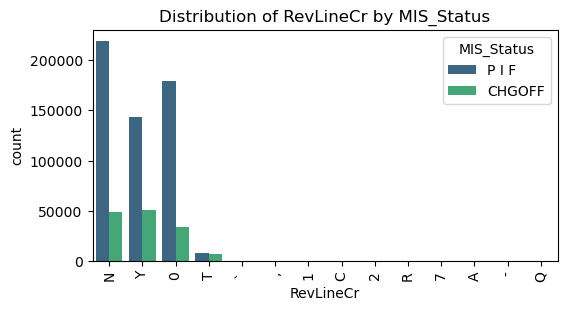

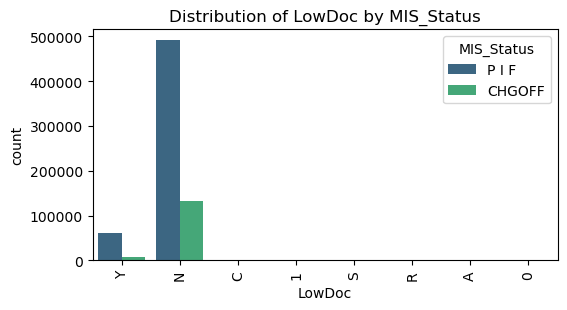

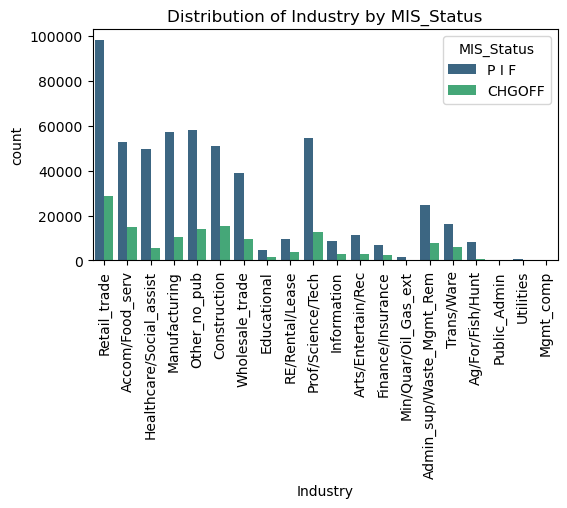

In [40]:
# Plot the relation between the categorical features and the target

# List of categorical columns
categorical_cols = ['State', 'BankState', 'RevLineCr', 'LowDoc', 'Industry']

for col in categorical_cols:
    plt.figure(figsize=(6, 3))
    sns.countplot(data=df, x=col, hue='MIS_Status', palette='viridis')
    plt.title(f'Distribution of {col} by MIS_Status')
    plt.xticks(rotation=90)  # Rotate x labels for better readability if needed
    plt.show()

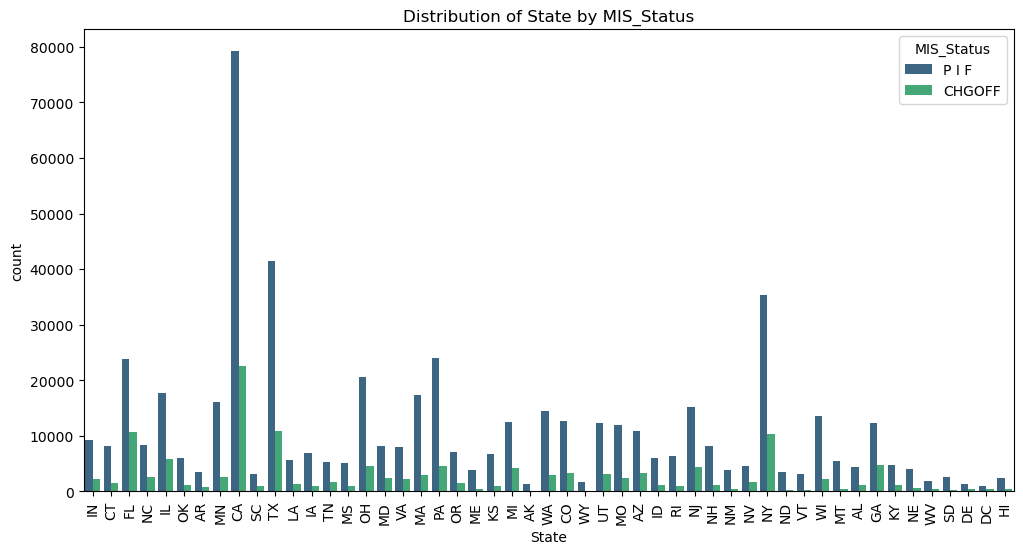

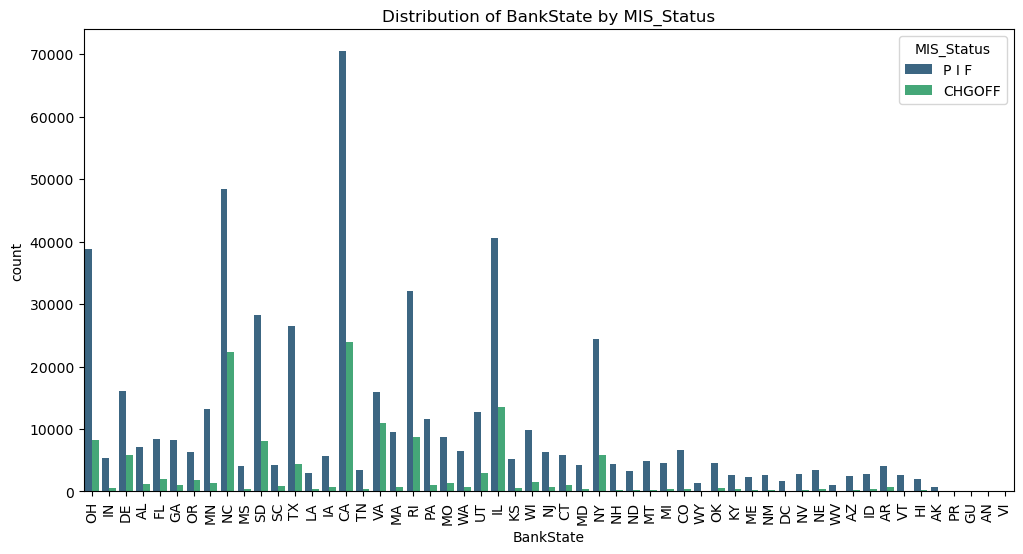

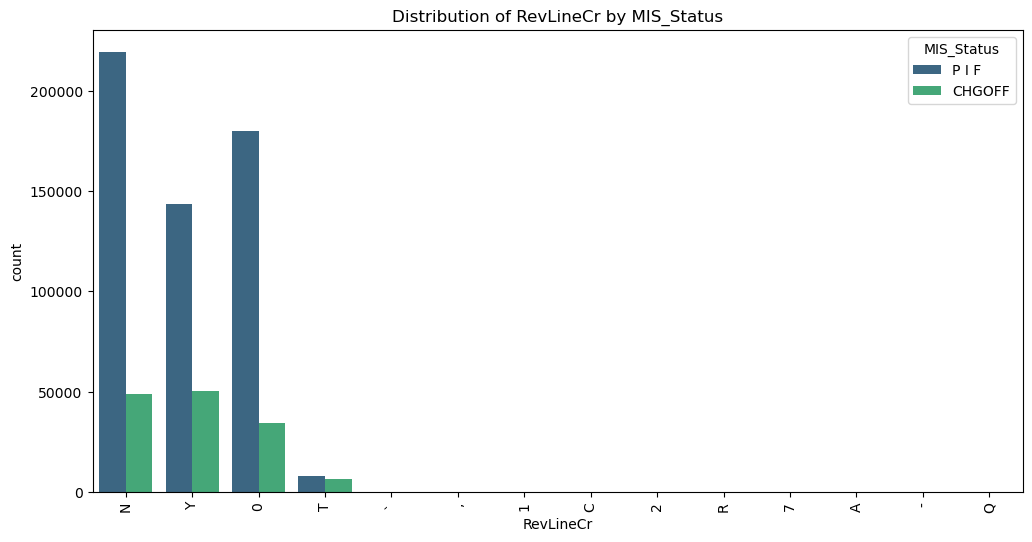

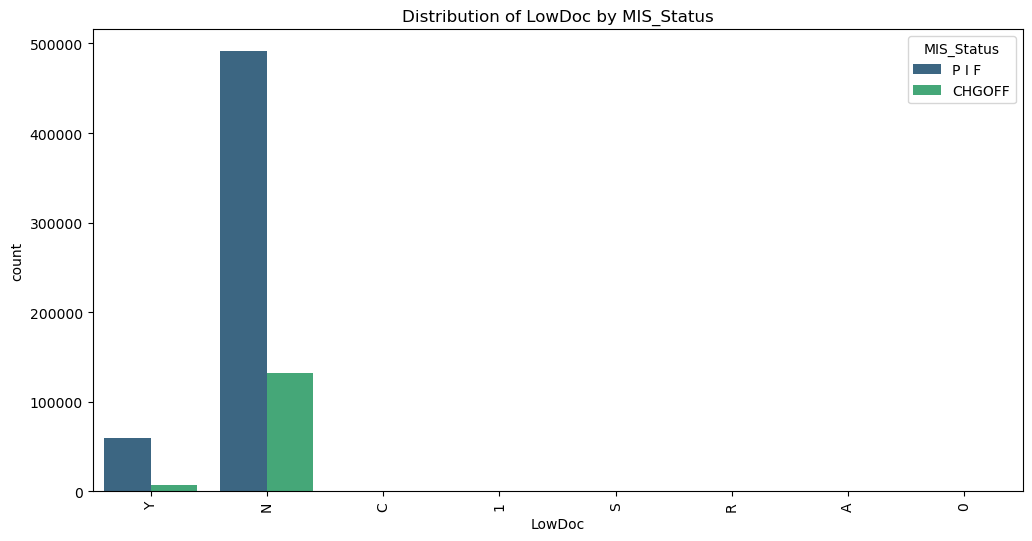

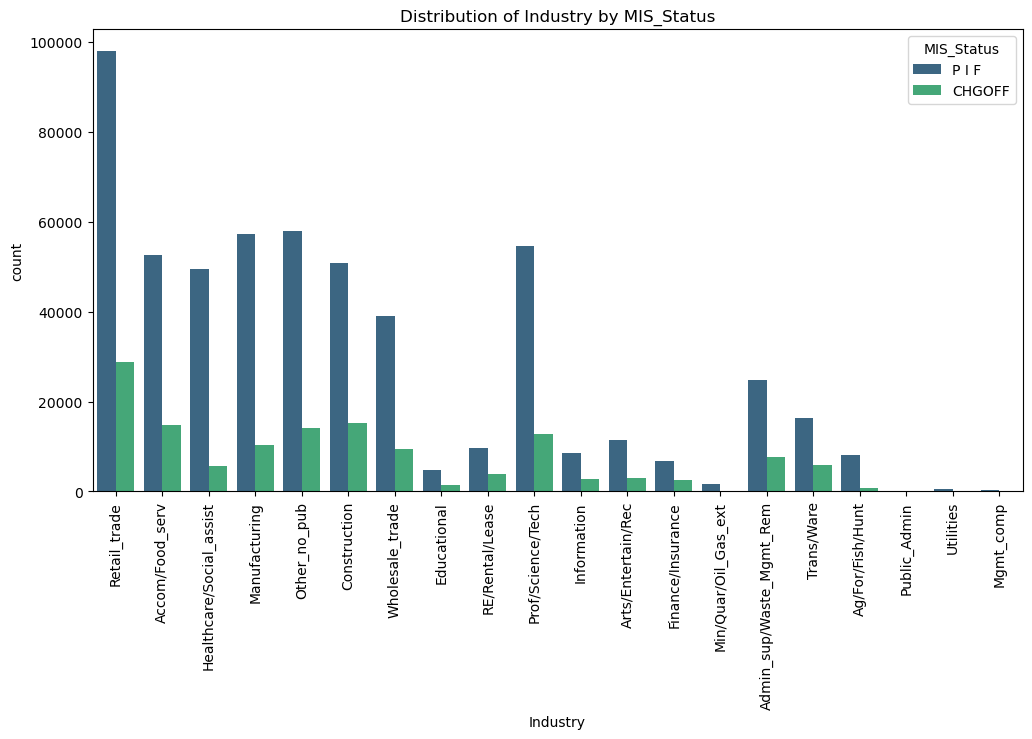

In [44]:
# Plot the relation between the categorical features and the target

# List of categorical columns
categorical_cols = ['State', 'BankState', 'RevLineCr', 'LowDoc', 'Industry']

for col in categorical_cols:
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, x=col, hue='MIS_Status', palette='viridis')
    plt.title(f'Distribution of {col} by MIS_Status')
    plt.xticks(rotation=90)  # Rotate x labels for better readability if needed
    plt.show()

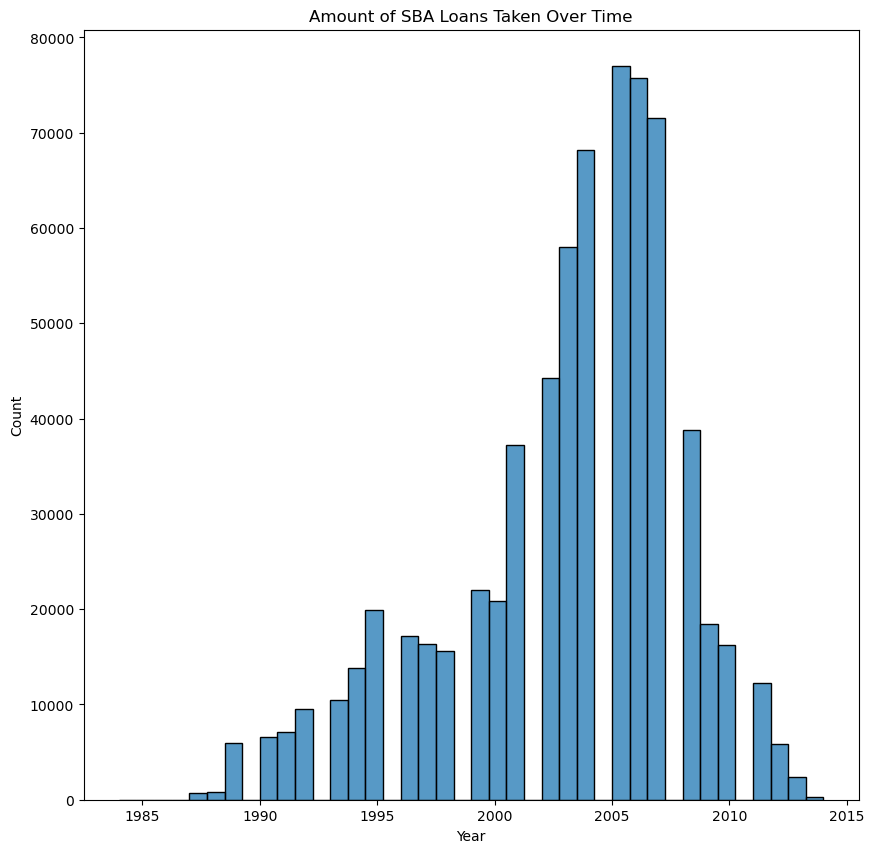

In [45]:
# Create a histogram plot using histplot
fig = plt.figure(figsize=(10,10))
sns.histplot(data=df['ApprovalFY'], bins=40, kde=False)

# Add labels and title
plt.title('Amount of SBA Loans Taken Over Time')
plt.ylabel('Count')
plt.xlabel('Year')
plt.show()


We can also observe a decrease in the amount of SBA loans taken after 2010. Even though the amount of loans taken decreased, the success rate was still very high, so we know that businesses that have taken out loans in the past few years are much less risky than before.



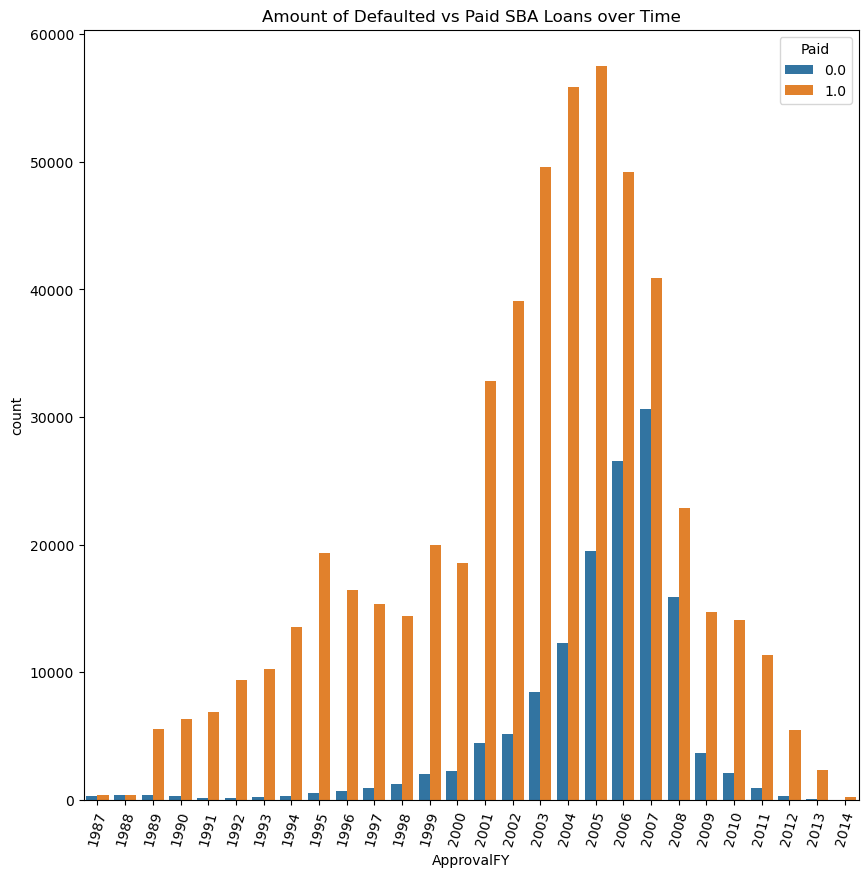

In [53]:
# Filter the dataframe for years greater than or equal to 1986
post_1985 = df[df['ApprovalFY'] >= 1986]

# Create the countplot
fig = plt.figure(figsize=(10,10))
sns.countplot(x="ApprovalFY", data=post_1985, hue="Paid")

# Add title and adjust the x-axis
plt.title('Amount of Defaulted vs Paid SBA Loans over Time')
plt.xticks(rotation=75)
plt.show()

1. Overall Trend: The number of paid loans is consistently higher than the number of defaulted loans throughout the period.
2.
Peak Period: Both paid and defaulted loans peaked between 2006 and 2008. This could be related to the economic conditions during that time, such as the financial crisis.
3.
Post-Peak Decline: After 2008, there is a noticeable decline in both paid and defaulted loans, indicating a possible tightening of lending practices or a decrease in loan demand.


In [56]:
# map the NAICS codes to their actual industries
df['NAICS'] = df['NAICS'].astype(str)
def first_two(string):
    s = string[:2]
    return s
df['NAICS'] = df['NAICS'].apply(lambda x: first_two(x))

dic = {'11': 'Agriculture, Fishing, Forestry, and Hunting',
      '21': 'Mining, Quarrying, Oil and Gas Extraction',
      '22': 'Utilities', '23': 'Construction', '31':'Manufacturing',
      '32': 'Manufacturing', '33': 'Manufacturing', '42': 'Wholesale Trade',
      '44': 'Retail Trade', '45':'Retail Trade', '48':'Transport and Warehouse',
      '49': 'Transport and Warehouse', '51':'Information',
      '52': 'Finance and Insurance', '53':'Real Estate and Rental Leasing',
      '54':'Profesisonal, Scientific, and Technical Services',
      '55':'Management', '56':'Administrative and Support and Waste Management',
      '61':'Educational Services', '62':'Health Care and Social Assistance',
      '71': 'Arts, Entertainment and Recreation', '72':'Accomodation and Food Services',
      '81': 'Other Services', '92':'Public Administration'}

df['NAICS'] = df['NAICS'].map(dic)

*This chart shows the average loan sizes for different industries. Larger loan sizes might indicate higher capital requirements or larger business operations in those industries.*

**A.Comparison with Paid in Full Rates:**

1. Finance & Insurance: This industry has high paid in full rates and moderate loan sizes. This suggests that businesses in this sector are reliable in repaying their loans and manage moderate loan amounts effectively.

2. Accommodation and Food Services: This industry has lower paid in full rates and relatively larger loan sizes. This could indicate that businesses in this sector face challenges in repaying larger loans, possibly due to higher operational risks or lower profit margins.

**Comparison with Loan Terms:**

1. Professional, Scientific & Technical Services: This industry shows high paid in full rates, moderate loan terms, and moderate loan sizes, indicating a stable financial performance and balanced approach to loan durations and sizes.

2. Arts, Entertainment & Recreation: This sector has lower paid in full rates, longer loan terms, and moderate loan sizes, suggesting potential financial instability or higher risk in loan repayments.



# Making sample

In [59]:
df["ApprovalFY"].unique()

array([1997, 2006, 1998, 1999, 2000, 2001, 2003, 2004, 2005, 1984, 2007,
       1987, 2008, 1988, 2009, 1989, 1990, 2010, 1991, 2011, 1992, 2002,
       2012, 1993, 2013, 1994, 2014, 1995, 1996])

In [60]:
def clean_str(x):
    if isinstance(x, str):
        return x.replace('A', '')
    return x

df.ApprovalFY = df.ApprovalFY.apply(clean_str).astype('int64')

In [61]:
df_sample = df[(df["ApprovalFY"] >= 2008) & (df["ApprovalFY"] <= 2010) ]
df_sample

,LoanNr_ChkDgt,Name,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,ApprovalFY,...,LowDoc,DisbursementDate,DisbursementGross,BalanceGross,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv,Industry,Paid
246012,2734655007,Jerome A. Cox and Cheryl L. Co,CASSVILLE,MO,65625,LIBERTY BANK,MO,Accomodation and Food Services,1-Oct-07,2008,...,N,NaT,127918.0,0.0,CHGOFF,48799.0,130000.0,110500.0,Accom/Food_serv,0.0
246015,2734675002,"Neal Group Construction, LLC,",Joplin,MO,64801,LIBERTY BANK,MO,Construction,1-Oct-07,2008,...,N,NaT,150000.0,0.0,P I F,0.0,150000.0,127500.0,Construction,1.0
246017,2734685005,"Whirled Piece, Inc - Inventory",FARGO,ND,58103,RAMSEY NATIONAL BANK,ND,Retail Trade,1-Oct-07,2008,...,N,NaT,21100.0,0.0,P I F,0.0,21100.0,10550.0,Retail_trade,1.0
246021,2734705009,cindy's art nail inc.,UNION CITY,NJ,7087,"PNC BANK, NATIONAL ASSOCIATION",DE,Other Services,1-Oct-07,2008,...,N,NaT,49533.0,0.0,CHGOFF,19666.0,20000.0,10000.0,Other_no_pub,0.0
246023,2734725004,"XENIA HOSPITALITY, LTD.",CANTON,OH,44702,"FIRSTMERIT BANK, N.A.",OH,Accomodation and Food Services,1-Oct-07,2008,...,N,NaT,30000.0,0.0,CHGOFF,10879.0,30000.0,15000.0,Accom/Food_serv,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440941,4280665003,Beef O'Brady's,Fernandina beach,FL,32034,CBC NATIONAL BANK,FL,Accomodation and Food Services,30-Sep-10,2010,...,N,NaT,75000.0,0.0,P I F,0.0,75000.0,37500.0,Accom/Food_serv,1.0
440943,4280675006,USA Martial Arts,Plano,TX,75093,COMPASS BANK,AL,"Arts, Entertainment and Recreation",30-Sep-10,2010,...,N,NaT,20000.0,0.0,CHGOFF,17504.0,20000.0,10000.0,Arts/Entertain/Rec,0.0
440945,4280685009,Jeremy Hilton,Belleville,AR,72824,FIRST FINANCIAL BANK,AR,"Agriculture, Fishing, Forestry, and Hunting",30-Sep-10,2010,...,N,NaT,10500.0,0.0,P I F,0.0,10500.0,5250.0,Ag/For/Fish/Hunt,1.0
440955,4280795007,"COMFORT INN OF MERIDIAN, INC",MERIDIAN,MS,39301,GREAT SOUTHERN NATIONAL BANK,MS,Accomodation and Food Services,30-Sep-10,2010,...,N,NaT,35000.0,0.0,P I F,0.0,35000.0,35000.0,Accom/Food_serv,1.0


In [62]:
df_sample.isna().sum()

LoanNr_ChkDgt            0
Name                     1
City                     0
State                    0
Zip                      0
Bank                     1
BankState                1
NAICS                    0
ApprovalDate             0
ApprovalFY               0
Term                     0
NoEmp                    0
NewExist                90
CreateJob                0
RetainedJob              0
FranchiseCode            0
UrbanRural               0
RevLineCr                0
LowDoc                   0
DisbursementDate     73471
DisbursementGross        0
BalanceGross             0
MIS_Status               0
ChgOffPrinGr             0
GrAppv                   0
SBA_Appv                 0
Industry                 0
Paid                     0
dtype: int64

In [63]:
df_sample["MIS_Status"].value_counts()

MIS_Status
P I F     51771
CHGOFF    21700
Name: count, dtype: int64

# Data collecting

In [65]:
data = pd.read_csv("SBAnational.csv", dtype={'column_name': str}, low_memory=False)
data

,LoanNr_ChkDgt,Name,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,ApprovalFY,...,RevLineCr,LowDoc,ChgOffDate,DisbursementDate,DisbursementGross,BalanceGross,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv
0,1000014003,ABC HOBBYCRAFT,EVANSVILLE,IN,47711,FIFTH THIRD BANK,OH,451120,28-Feb-97,1997,...,N,Y,NaN,28-Feb-99,"$60,000.00",$0.00,P I F,$0.00,"$60,000.00","$48,000.00"
1,1000024006,LANDMARK BAR & GRILLE (THE),NEW PARIS,IN,46526,1ST SOURCE BANK,IN,722410,28-Feb-97,1997,...,N,Y,NaN,31-May-97,"$40,000.00",$0.00,P I F,$0.00,"$40,000.00","$32,000.00"
2,1000034009,"WHITLOCK DDS, TODD M.",BLOOMINGTON,IN,47401,GRANT COUNTY STATE BANK,IN,621210,28-Feb-97,1997,...,N,N,NaN,31-Dec-97,"$287,000.00",$0.00,P I F,$0.00,"$287,000.00","$215,250.00"
3,1000044001,"BIG BUCKS PAWN & JEWELRY, LLC",BROKEN ARROW,OK,74012,1ST NATL BK & TR CO OF BROKEN,OK,0,28-Feb-97,1997,...,N,Y,NaN,30-Jun-97,"$35,000.00",$0.00,P I F,$0.00,"$35,000.00","$28,000.00"
4,1000054004,"ANASTASIA CONFECTIONS, INC.",ORLANDO,FL,32801,FLORIDA BUS. DEVEL CORP,FL,0,28-Feb-97,1997,...,N,N,NaN,14-May-97,"$229,000.00",$0.00,P I F,$0.00,"$229,000.00","$229,000.00"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
899159,9995573004,FABRIC FARMS,UPPER ARLINGTON,OH,43221,JPMORGAN CHASE BANK NATL ASSOC,IL,451120,27-Feb-97,1997,...,0,N,NaN,30-Sep-97,"$70,000.00",$0.00,P I F,$0.00,"$70,000.00","$56,000.00"
899160,9995603000,FABRIC FARMS,COLUMBUS,OH,43221,JPMORGAN CHASE BANK NATL ASSOC,IL,451130,27-Feb-97,1997,...,Y,N,NaN,31-Oct-97,"$85,000.00",$0.00,P I F,$0.00,"$85,000.00","$42,500.00"
899161,9995613003,"RADCO MANUFACTURING CO.,INC.",SANTA MARIA,CA,93455,"RABOBANK, NATIONAL ASSOCIATION",CA,332321,27-Feb-97,1997,...,N,N,NaN,30-Sep-97,"$300,000.00",$0.00,P I F,$0.00,"$300,000.00","$225,000.00"
899162,9995973006,"MARUTAMA HAWAII, INC.",HONOLULU,HI,96830,BANK OF HAWAII,HI,0,27-Feb-97,1997,...,N,Y,8-Mar-00,31-Mar-97,"$75,000.00",$0.00,CHGOFF,"$46,383.00","$75,000.00","$60,000.00"


In [66]:
df_sample = data.copy()

In [67]:
df_sample.shape

(899164, 27)

In [68]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 899164 entries, 0 to 899163
Data columns (total 27 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   LoanNr_ChkDgt      899164 non-null  int64  
 1   Name               899150 non-null  object 
 2   City               899134 non-null  object 
 3   State              899150 non-null  object 
 4   Zip                899164 non-null  int64  
 5   Bank               897605 non-null  object 
 6   BankState          897598 non-null  object 
 7   NAICS              899164 non-null  int64  
 8   ApprovalDate       899164 non-null  object 
 9   ApprovalFY         899164 non-null  object 
 10  Term               899164 non-null  int64  
 11  NoEmp              899164 non-null  int64  
 12  NewExist           899028 non-null  float64
 13  CreateJob          899164 non-null  int64  
 14  RetainedJob        899164 non-null  int64  
 15  FranchiseCode      899164 non-null  int64  
 16  Ur

In [69]:
df_sample.describe().T

,count,mean,std,min,25%,50%,75%,max
LoanNr_ChkDgt,899164.0,4.772612e+09,2.538175e+09,1.000014e+09,2.589758e+09,4.361439e+09,6.904627e+09,9.996003e+09
Zip,899164.0,5.380439e+04,3.118416e+04,0.000000e+00,2.758700e+04,5.541000e+04,8.370400e+04,9.999900e+04
NAICS,899164.0,3.986610e+05,2.633183e+05,0.000000e+00,2.352100e+05,4.453100e+05,5.617300e+05,9.281200e+05
Term,899164.0,1.107731e+02,7.885731e+01,0.000000e+00,6.000000e+01,8.400000e+01,1.200000e+02,5.690000e+02
NoEmp,899164.0,1.141135e+01,7.410820e+01,0.000000e+00,2.000000e+00,4.000000e+00,1.000000e+01,9.999000e+03
NewExist,899028.0,1.280404e+00,4.517500e-01,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00
CreateJob,899164.0,8.430376e+00,2.366882e+02,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,8.800000e+03
RetainedJob,899164.0,1.079726e+01,2.371206e+02,0.000000e+00,0.000000e+00,1.000000e+00,4.000000e+00,9.500000e+03
FranchiseCode,899164.0,2.753726e+03,1.275802e+04,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,9.999900e+04
UrbanRural,899164.0,7.577483e-01,6.464360e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00


In [70]:
df_sample.describe(include='object')

,Name,City,State,Bank,BankState,ApprovalDate,ApprovalFY,RevLineCr,LowDoc,ChgOffDate,DisbursementDate,DisbursementGross,BalanceGross,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv
count,899150,899134,899150,897605,897598,899164,899164,894636,896582,162699,896796,899164,899164,897167,899164,899164,899164
unique,779583,32581,51,5802,56,9859,52,18,8,6448,8472,118859,15,2,83165,22128,38326
top,SUBWAY,LOS ANGELES,CA,BANK OF AMERICA NATL ASSOC,CA,7-Jul-93,2005,N,N,13-Mar-10,31-Jul-95,"$50,000.00",$0.00,P I F,$0.00,"$50,000.00","$25,000.00"
freq,1269,11558,130619,86853,118116,1131,77525,420288,782822,734,10371,43787,899150,739609,737152,69394,49579


# Data Preprocessing

## Handling values in some columns

In [75]:
df_sample[['DisbursementGross', 'BalanceGross', 'ChgOffPrinGr', 'GrAppv', 'SBA_Appv']].head()

,DisbursementGross,BalanceGross,ChgOffPrinGr,GrAppv,SBA_Appv
0,"$60,000.00",$0.00,$0.00,"$60,000.00","$48,000.00"
1,"$40,000.00",$0.00,$0.00,"$40,000.00","$32,000.00"
2,"$287,000.00",$0.00,$0.00,"$287,000.00","$215,250.00"
3,"$35,000.00",$0.00,$0.00,"$35,000.00","$28,000.00"
4,"$229,000.00",$0.00,$0.00,"$229,000.00","$229,000.00"


- The amount columns are represented as categorical features so we change them to numerical features

- The first two digits of the NAICS classification represent the economic sector.
- So We extract two digits and map it to its industry

In [78]:
df_sample['ApprovalFY'].apply(type).value_counts()

ApprovalFY
<class 'str'>    899164
Name: count, dtype: int64

In [79]:
df_sample.ApprovalFY.unique()

array(['1997', '1980', '2006', '1998', '1999', '2000', '2001', '1972',
       '2003', '2004', '1978', '1979', '1981', '2005', '1962', '1982',
       '1965', '1966', '1983', '1973', '1984', '2007', '1985', '1986',
       '1987', '2008', '1988', '2009', '1989', '1991', '1990', '1974',
       '2010', '1967', '2011', '1992', '1993', '2002', '2012', '2013',
       '1994', '2014', '1975', '1977', '1976', '1968', '1976A', '1969',
       '1995', '1970', '1996', '1971'], dtype=object)

In [80]:
df_sample.FranchiseCode.unique()

array([    1,     0, 15100, ...,  2899, 18701, 15930])

In [81]:
df_sample["FranchiseCode"].value_counts()

FranchiseCode
1        638554
0        208835
78760      3373
68020      1921
50564      1034
          ...  
24421         1
61615         1
81580         1
83876         1
15930         1
Name: count, Length: 2768, dtype: int64

In [82]:
df_sample.loc[(df_sample['FranchiseCode'] <= 1), 'IsFranchise'] = 0
df_sample.loc[(df_sample['FranchiseCode'] > 1), 'IsFranchise'] = 1

In [83]:
df_sample['IsFranchise'].value_counts()

IsFranchise
0.0    847389
1.0     51775
Name: count, dtype: int64

In [84]:
df_sample['NewExist'].unique()

array([ 2.,  1.,  0., nan])

In [85]:
df_sample['NewExist'] = np.where(df_sample['NewExist'] == 1, 0,
                                np.where(df_sample['NewExist'] == 2, 1, np.nan))

In [86]:
df_sample['NewExist'].value_counts()

NewExist
0.0    644869
1.0    253125
Name: count, dtype: int64

In [87]:
df_sample['RevLineCr'].unique()

array(['N', '0', 'Y', 'T', nan, '`', ',', '1', 'C', '3', '2', 'R', '7',
       'A', '5', '.', '4', '-', 'Q'], dtype=object)

In [88]:
df_sample['RevLineCr'] = np.where(df_sample['RevLineCr'] == 'Y', 1,
                                np.where(df_sample['RevLineCr'] == 'N', 0, np.nan))

In [89]:
df_sample['RevLineCr'].value_counts()

RevLineCr
0.0    420288
1.0    201397
Name: count, dtype: int64

In [91]:
df_sample['LowDoc'].unique()

array(['Y', 'N', 'C', '1', nan, 'S', 'R', 'A', '0'], dtype=object)

In [92]:
df_sample['LowDoc'] = np.where(df_sample['LowDoc'] == 'Y', 1,
                                np.where(df_sample['LowDoc'] == 'N', 0, np.nan))

In [93]:
df_sample.RevLineCr.unique()


array([ 0., nan,  1.])

In [94]:
df_sample.LowDoc.unique()

array([ 1.,  0., nan])

## Handling Date columns

In [96]:
df_sample['ApprovalDate'] = pd.to_datetime(df_sample['ApprovalDate'], format='%d-%b-%y')
df_sample['DisbursementDate'] = pd.to_datetime(df_sample['DisbursementDate'], format='%d-%b-%y')
df_sample['DaysToDisbursement'] = df_sample['DisbursementDate'] - df_sample['ApprovalDate']

In [97]:
df_sample['DaysToDisbursement'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 899164 entries, 0 to 899163
Series name: DaysToDisbursement
Non-Null Count   Dtype          
--------------   -----          
896796 non-null  timedelta64[ns]
dtypes: timedelta64[ns](1)
memory usage: 6.9 MB


In [98]:
df_sample['DaysToDisbursement']=df_sample['DaysToDisbursement'].dt.days


In [99]:
df_sample['DisbursementFY'] = df_sample['DisbursementDate'].map(lambda x: x.year)

In [100]:
df_sample[df_sample["DaysToDisbursement"] < 0]

,LoanNr_ChkDgt,Name,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,ApprovalFY,...,DisbursementDate,DisbursementGross,BalanceGross,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv,IsFranchise,DaysToDisbursement,DisbursementFY
481,1003703008,"AQUA BELLA ENTERPRISES, INC.",CHICAGO,IL,60634,NORTH COMMUNITY BANK,IL,0,1980-06-25,1980,...,1980-05-12,"$350,000.00",$0.00,CHGOFF,"$311,636.00","$350,000.00","$315,000.00",0.0,-44.0,1980.0
1548,1010634005,EARL'S MACHINE SHOP,ROGERS,AR,72756,IBERIABANK,AR,332312,1997-03-05,1997,...,1997-02-28,"$56,400.00",$0.00,P I F,$0.00,"$56,400.00","$45,120.00",0.0,-5.0,1997.0
1655,1011204007,MACHINE SHOP SERVICES INC,NEENAH,WI,54956,AMER NATL BANK-FOX CITIES,WI,333512,1997-03-05,1997,...,1997-02-28,"$27,000.00",$0.00,P I F,$0.00,"$27,000.00","$21,600.00",0.0,-5.0,1997.0
6907,1047134001,ADVANTAGE ASIA,NEW YORK,NY,10028,JPMORGAN CHASE BANK NATL ASSOC,IL,0,1997-03-19,1997,...,1997-02-14,"$75,000.00",$0.00,P I F,$0.00,"$75,000.00","$60,000.00",0.0,-33.0,1997.0
13804,1098814004,LANSING CONSTRUCTION,MONTEZUMZ CREEK,UT,84510,VECTRA BK COLORADO NATL ASSOC,NM,235930,1997-04-04,1997,...,1996-07-04,"$40,600.00",$0.00,P I F,$0.00,"$40,600.00","$32,480.00",0.0,-274.0,1996.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
896648,9939483007,AUTO AUCTION DIRECT,AMERICAN FORK,UT,84003,1ST NATL BK OF LAYTON,UT,441120,1997-02-03,1997,...,1996-04-07,"$125,000.00",$0.00,CHGOFF,"$118,002.00","$125,000.00","$93,750.00",0.0,-302.0,1996.0
896854,9944333002,MADDEN PRINTING/MINUTEMAN PRES,FISHKILL,NY,12524,"PNC BANK, NATIONAL ASSOCIATION",NJ,0,1997-02-05,1997,...,1996-10-29,"$90,000.00",$0.00,P I F,$0.00,"$90,000.00","$72,000.00",0.0,-99.0,1996.0
897223,9952913010,"RODCO, INC",CENTERVILLE,UT,84014,1ST NATL BK OF LAYTON,UT,233210,1997-02-10,1997,...,1996-04-13,"$180,000.00",$0.00,P I F,$0.00,"$180,000.00","$135,000.00",0.0,-303.0,1996.0
898373,9978813002,"CROWN JEWELERS, LTD.",STAUNTON,VA,24401,UNION FIRST MARKET BANK,VA,448310,1997-02-21,1997,...,1987-04-01,"$50,000.00",$0.00,P I F,$0.00,"$50,000.00","$37,500.00",0.0,-3614.0,1987.0


- These rows are considered invalid, because they indicate that the loan was disbursed before it was approved -> drop it.

In [102]:
df_sample.drop(df_sample[df_sample["DaysToDisbursement"] < 0].index, inplace=True)
df_sample

,LoanNr_ChkDgt,Name,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,ApprovalFY,...,DisbursementDate,DisbursementGross,BalanceGross,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv,IsFranchise,DaysToDisbursement,DisbursementFY
0,1000014003,ABC HOBBYCRAFT,EVANSVILLE,IN,47711,FIFTH THIRD BANK,OH,451120,1997-02-28,1997,...,1999-02-28,"$60,000.00",$0.00,P I F,$0.00,"$60,000.00","$48,000.00",0.0,730.0,1999.0
1,1000024006,LANDMARK BAR & GRILLE (THE),NEW PARIS,IN,46526,1ST SOURCE BANK,IN,722410,1997-02-28,1997,...,1997-05-31,"$40,000.00",$0.00,P I F,$0.00,"$40,000.00","$32,000.00",0.0,92.0,1997.0
2,1000034009,"WHITLOCK DDS, TODD M.",BLOOMINGTON,IN,47401,GRANT COUNTY STATE BANK,IN,621210,1997-02-28,1997,...,1997-12-31,"$287,000.00",$0.00,P I F,$0.00,"$287,000.00","$215,250.00",0.0,306.0,1997.0
3,1000044001,"BIG BUCKS PAWN & JEWELRY, LLC",BROKEN ARROW,OK,74012,1ST NATL BK & TR CO OF BROKEN,OK,0,1997-02-28,1997,...,1997-06-30,"$35,000.00",$0.00,P I F,$0.00,"$35,000.00","$28,000.00",0.0,122.0,1997.0
4,1000054004,"ANASTASIA CONFECTIONS, INC.",ORLANDO,FL,32801,FLORIDA BUS. DEVEL CORP,FL,0,1997-02-28,1997,...,1997-05-14,"$229,000.00",$0.00,P I F,$0.00,"$229,000.00","$229,000.00",0.0,75.0,1997.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
899159,9995573004,FABRIC FARMS,UPPER ARLINGTON,OH,43221,JPMORGAN CHASE BANK NATL ASSOC,IL,451120,1997-02-27,1997,...,1997-09-30,"$70,000.00",$0.00,P I F,$0.00,"$70,000.00","$56,000.00",0.0,215.0,1997.0
899160,9995603000,FABRIC FARMS,COLUMBUS,OH,43221,JPMORGAN CHASE BANK NATL ASSOC,IL,451130,1997-02-27,1997,...,1997-10-31,"$85,000.00",$0.00,P I F,$0.00,"$85,000.00","$42,500.00",0.0,246.0,1997.0
899161,9995613003,"RADCO MANUFACTURING CO.,INC.",SANTA MARIA,CA,93455,"RABOBANK, NATIONAL ASSOCIATION",CA,332321,1997-02-27,1997,...,1997-09-30,"$300,000.00",$0.00,P I F,$0.00,"$300,000.00","$225,000.00",0.0,215.0,1997.0
899162,9995973006,"MARUTAMA HAWAII, INC.",HONOLULU,HI,96830,BANK OF HAWAII,HI,0,1997-02-27,1997,...,1997-03-31,"$75,000.00",$0.00,CHGOFF,"$46,383.00","$75,000.00","$60,000.00",0.0,32.0,1997.0


## Feature Engineering

In [104]:
df_sample['Industry']=df_sample['NAICS'].astype('str').apply(lambda x: x[:2])

In [105]:
df_sample['Industry'] = df_sample['Industry'].map({
    '11': 'Ag/For/Fish/Hunt',
    '21': 'Min/Quar/Oil_Gas_ext',
    '22': 'Utilities',
    '23': 'Construction',
    '31': 'Manufacturing',
    '32': 'Manufacturing',
    '33': 'Manufacturing',
    '42': 'Wholesale_trade',
    '44': 'Retail_trade',
    '45': 'Retail_trade',
    '48': 'Trans/Ware',
    '49': 'Trans/Ware',
    '51': 'Information',
    '52': 'Finance/Insurance',
    '53': 'RE/Rental/Lease',
    '54': 'Prof/Science/Tech',
    '55': 'Mgmt_comp',
    '56': 'Admin_sup/Waste_Mgmt_Rem',
    '61': 'Educational',
    '62': 'Healthcare/Social_assist',
    '71': 'Arts/Entertain/Rec',
    '72': 'Accom/Food_serv',
    '81': 'Other_no_pub',
    '92': 'Public_Admin'
})

In [ ]:
df_sample['SBA_Appv'] = df_sample['SBA_Appv'].str.extract("(\d+)").astype(int)

In [ ]:
df_sample['GrAppv'] = df_sample['GrAppv'].str.extract("(\d+)").astype(int)

In [108]:
df_sample['SBA_AppvPct'] = df_sample['SBA_Appv'] / df_sample['GrAppv']

In [ ]:
df_sample['ChgOffPrinGr'] = df_sample['ChgOffPrinGr'].str.extract("(\d+)").astype(int)

In [ ]:
df_sample['DisbursementGross'] = df_sample['DisbursementGross'].str.extract("(\d+)").astype(int)

In [111]:
df_sample['AppvDisbursed'] = np.where(df_sample['DisbursementGross'] == df_sample['GrAppv'], 1, 0)

In [112]:
df_sample['RealEstate'] = np.where(df_sample['Term'] >= 240, 1, 0)

In [113]:
df_sample["TotalJobs"] = df_sample["CreateJob"] + df_sample["RetainedJob"]

In [114]:
df_sample["TermYears"] = df_sample["Term"] / 12

In [115]:
df_sample["ChgOffPrinGr"].value_counts()

ChgOffPrinGr
0      736413
9        5594
24       5446
4        5356
49       3806
        ...  
909         1
961         1
742         1
972         1
945         1
Name: count, Length: 996, dtype: int64

In [116]:
df_sample[df_sample["ChgOffPrinGr"] > 0]["MIS_Status"].value_counts()

MIS_Status
CHGOFF    156804
P I F       4882
Name: count, dtype: int64

In [117]:
df_sample["DisbGrossRatio"] = df_sample["DisbursementGross"] /  df_sample["GrAppv"]

In [118]:
df_sample[df_sample["DisbGrossRatio"] > 1]["DisbGrossRatio"]

28        4.380000
30        1.457143
34        2.520000
48        1.200000
65        2.600000
            ...   
898434    1.070000
898534    1.057143
898580    1.555000
898679    4.180000
899134    1.250000
Name: DisbGrossRatio, Length: 148874, dtype: float64

- When the values ​​of this column are greater than 1, this means that the value of the disbursed amount is greater than the amount approved by the bank.
- This may indicate that there is an error in the calculations or that additional expenses have been incurred due to extending the loan period or any other reason.

## Data Cleaning

In [122]:
df_sample.columns

Index(['LoanNr_ChkDgt', 'Name', 'City', 'State', 'Zip', 'Bank', 'BankState',
       'NAICS', 'ApprovalDate', 'ApprovalFY', 'Term', 'NoEmp', 'NewExist',
       'CreateJob', 'RetainedJob', 'FranchiseCode', 'UrbanRural', 'RevLineCr',
       'LowDoc', 'ChgOffDate', 'DisbursementDate', 'DisbursementGross',
       'BalanceGross', 'MIS_Status', 'ChgOffPrinGr', 'GrAppv', 'SBA_Appv',
       'IsFranchise', 'DaysToDisbursement', 'DisbursementFY', 'Industry',
       'SBA_AppvPct', 'AppvDisbursed', 'RealEstate', 'TotalJobs', 'TermYears',
       'DisbGrossRatio'],
      dtype='object')

In [123]:
df_sample.drop(columns=['LoanNr_ChkDgt', 'Name', 'City', 'Zip', 'Bank', 'NAICS', 'ApprovalDate', 'FranchiseCode',
                      'ChgOffDate', 'DisbursementDate','SBA_Appv', "Term", "CreateJob", "RetainedJob", "BalanceGross", "GrAppv", "LowDoc"], inplace=True)

In [125]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 898356 entries, 0 to 899163
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   State               898342 non-null  object 
 1   BankState           896791 non-null  object 
 2   ApprovalFY          898356 non-null  object 
 3   NoEmp               898356 non-null  int64  
 4   NewExist            897188 non-null  float64
 5   UrbanRural          898356 non-null  int64  
 6   RevLineCr           621088 non-null  float64
 7   DisbursementGross   898356 non-null  int64  
 8   MIS_Status          896360 non-null  object 
 9   ChgOffPrinGr        898356 non-null  int64  
 10  IsFranchise         898356 non-null  float64
 11  DaysToDisbursement  895988 non-null  float64
 12  DisbursementFY      895988 non-null  float64
 13  Industry            696698 non-null  object 
 14  SBA_AppvPct         898356 non-null  float64
 15  AppvDisbursed       898356 non-null  in

In [126]:
df_sample.isnull().sum() / len(df_sample) * 100

State                  0.001558
BankState              0.174207
ApprovalFY             0.000000
NoEmp                  0.000000
NewExist               0.130015
UrbanRural             0.000000
RevLineCr             30.863934
DisbursementGross      0.000000
MIS_Status             0.222184
ChgOffPrinGr           0.000000
IsFranchise            0.000000
DaysToDisbursement     0.263593
DisbursementFY         0.263593
Industry              22.447448
SBA_AppvPct            0.000000
AppvDisbursed          0.000000
RealEstate             0.000000
TotalJobs              0.000000
TermYears              0.000000
DisbGrossRatio         0.000000
dtype: float64

In [127]:
missing_rows = df_sample[['BankState','NewExist','MIS_Status','DaysToDisbursement','DisbursementFY', 'Industry']].isnull().any(axis=1).sum()


total_rows = len(data)
percentage_missing = (missing_rows / total_rows) * 100
print(f"Missing rows: {missing_rows}")
print(f"Total rows: {total_rows}")
print(f"Percentage of missing rows: {percentage_missing:.2f}%")

Missing rows: 206737
Total rows: 899164
Percentage of missing rows: 22.99%


In [128]:
df_sample.dropna(subset=['BankState','NewExist','MIS_Status','DaysToDisbursement','DisbursementFY', 'Industry'],inplace=True)

In [129]:
missing_rows = df_sample[['RevLineCr']].isnull().any(axis=1).sum()


total_rows = len(data)
percentage_missing = (missing_rows / total_rows) * 100
print(f"Missing rows: {missing_rows}")
print(f"Total rows: {total_rows}")
print(f"Percentage of missing rows: {percentage_missing:.2f}%")

Missing rows: 230815
Total rows: 899164
Percentage of missing rows: 25.67%


In [131]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 691619 entries, 0 to 899161
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   State               691611 non-null  object 
 1   BankState           691619 non-null  object 
 2   ApprovalFY          691619 non-null  object 
 3   NoEmp               691619 non-null  int64  
 4   NewExist            691619 non-null  float64
 5   UrbanRural          691619 non-null  int64  
 6   RevLineCr           460804 non-null  float64
 7   DisbursementGross   691619 non-null  int64  
 8   MIS_Status          691619 non-null  object 
 9   ChgOffPrinGr        691619 non-null  int64  
 10  IsFranchise         691619 non-null  float64
 11  DaysToDisbursement  691619 non-null  float64
 12  DisbursementFY      691619 non-null  float64
 13  Industry            691619 non-null  object 
 14  SBA_AppvPct         691619 non-null  float64
 15  AppvDisbursed       691619 non-null  in

In [132]:
col_mode = ['RevLineCr']
# Fill missing values in the 'RevLineCr' column with the mode value
df_sample['RevLineCr'] = df_sample['RevLineCr'].fillna(df_sample['RevLineCr'].mode()[0])

In [133]:
df_sample.isna().sum()

State                 8
BankState             0
ApprovalFY            0
NoEmp                 0
NewExist              0
UrbanRural            0
RevLineCr             0
DisbursementGross     0
MIS_Status            0
ChgOffPrinGr          0
IsFranchise           0
DaysToDisbursement    0
DisbursementFY        0
Industry              0
SBA_AppvPct           0
AppvDisbursed         0
RealEstate            0
TotalJobs             0
TermYears             0
DisbGrossRatio        0
dtype: int64

In [136]:
df_sample = df_sample.astype({'IsFranchise': 'int64', 'NewExist': 'int64','DaysToDisbursement':'int64','DisbursementFY':'int64','RevLineCr':'int64'})

In [138]:
df_sample.dtypes

State                  object
BankState              object
ApprovalFY             object
NoEmp                   int64
NewExist                int64
UrbanRural              int64
RevLineCr               int64
DisbursementGross       int64
MIS_Status             object
ChgOffPrinGr            int64
IsFranchise             int64
DaysToDisbursement      int64
DisbursementFY          int64
Industry               object
SBA_AppvPct           float64
AppvDisbursed           int64
RealEstate              int64
TotalJobs               int64
TermYears             float64
DisbGrossRatio        float64
dtype: object

In [142]:
df_sample.shape

(691619, 20)

In [143]:
for column in df_sample.select_dtypes(include=['object']).columns:
    print(f"Distribution of {column}:")
    print(df_sample[column].value_counts())
    print()

Distribution of State:
State
CA    101358
TX     52330
NY     45465
FL     34401
PA     28319
OH     25209
IL     23542
MA     20320
NJ     19613
MN     18627
WA     17283
GA     17084
MI     16740
CO     15873
WI     15731
UT     15440
MO     14411
AZ     14164
IN     11515
NC     10924
MD     10607
VA     10411
CT      9629
NH      9340
OR      8571
IA      7987
KS      7814
OK      7264
RI      7245
ID      7064
LA      7032
TN      7017
NV      6231
MS      6148
KY      5966
MT      5810
AL      5608
NE      4702
AR      4400
ME      4376
NM      4294
SC      4226
ND      3698
VT      3383
SD      2889
HI      2882
WV      2262
WY      1906
DE      1723
AK      1445
DC      1332
Name: count, dtype: int64

Distribution of BankState:
BankState
CA    94726
NC    70701
IL    53625
OH    47055
RI    40649
SD    36239
TX    30918
NY    30238
VA    26919
DE    21958
UT    15736
MN    14553
PA    12538
WI    11379
FL    10333
MA    10267
MO    10072
GA     9245
AL     8427
OR     8238
CO  

## Handling duplicates

In [145]:
df_sample.duplicated().sum()

288

In [146]:
df_sample.drop_duplicates(inplace=True)

In [147]:
df_sample.duplicated().sum()

0

## Binning some values

In [149]:
df_sample_bin = df_sample.copy()

In [150]:
df_sample_bin.head()

,State,BankState,ApprovalFY,NoEmp,NewExist,UrbanRural,RevLineCr,DisbursementGross,MIS_Status,ChgOffPrinGr,IsFranchise,DaysToDisbursement,DisbursementFY,Industry,SBA_AppvPct,AppvDisbursed,RealEstate,TotalJobs,TermYears,DisbGrossRatio
0,IN,OH,1997,4,1,0,0,60,P I F,0,0,730,1999,Retail_trade,0.800000,1,0,0,7.0,1.0
1,IN,IN,1997,2,1,0,0,40,P I F,0,0,92,1997,Accom/Food_serv,0.800000,1,0,0,5.0,1.0
2,IN,IN,1997,7,0,0,0,287,P I F,0,0,306,1997,Healthcare/Social_assist,0.749129,1,0,0,15.0,1.0
5,CT,DE,1997,19,0,0,0,517,P I F,0,0,122,1997,Manufacturing,0.748549,1,0,0,10.0,1.0
7,FL,AL,1997,1,1,0,0,45,P I F,0,0,487,1998,Other_no_pub,0.800000,1,0,0,7.0,1.0


In [ ]:
df_sample_bin["NoEmp"].unique()
sorted(df_sample_bin["NoEmp"].unique())

In [152]:
bins = [0, 50, 250, 1000, 4847]
labels = ['Small', 'Medium', 'Large', 'Very Large']

df_sample_bin['NumEmp_binned'] = pd.cut(df_sample_bin['NoEmp'], bins=bins, labels=labels, include_lowest=True)
df_sample_bin.head()

,State,BankState,ApprovalFY,NoEmp,NewExist,UrbanRural,RevLineCr,DisbursementGross,MIS_Status,ChgOffPrinGr,...,DaysToDisbursement,DisbursementFY,Industry,SBA_AppvPct,AppvDisbursed,RealEstate,TotalJobs,TermYears,DisbGrossRatio,NumEmp_binned
0,IN,OH,1997,4,1,0,0,60,P I F,0,...,730,1999,Retail_trade,0.800000,1,0,0,7.0,1.0,Small
1,IN,IN,1997,2,1,0,0,40,P I F,0,...,92,1997,Accom/Food_serv,0.800000,1,0,0,5.0,1.0,Small
2,IN,IN,1997,7,0,0,0,287,P I F,0,...,306,1997,Healthcare/Social_assist,0.749129,1,0,0,15.0,1.0,Small
5,CT,DE,1997,19,0,0,0,517,P I F,0,...,122,1997,Manufacturing,0.748549,1,0,0,10.0,1.0,Small
7,FL,AL,1997,1,1,0,0,45,P I F,0,...,487,1998,Other_no_pub,0.800000,1,0,0,7.0,1.0,Small


In [ ]:
df_sample_bin["TermYears"].unique()
sorted(df_sample_bin["TermYears"].unique())

In [154]:
bins = [0, 5, 15, 27]
labels = ['Short Term', 'Medium Term', 'Large Term']

# Apply binning
df_sample_bin['TermYears_binned'] = pd.cut(df_sample_bin['TermYears'], bins=bins, labels=labels, include_lowest=True)

In [155]:
df_sample.columns

Index(['State', 'BankState', 'ApprovalFY', 'NoEmp', 'NewExist', 'UrbanRural',
       'RevLineCr', 'DisbursementGross', 'MIS_Status', 'ChgOffPrinGr',
       'IsFranchise', 'DaysToDisbursement', 'DisbursementFY', 'Industry',
       'SBA_AppvPct', 'AppvDisbursed', 'RealEstate', 'TotalJobs', 'TermYears',
       'DisbGrossRatio'],
      dtype='object')

In [ ]:
sorted(df_sample_bin["DaysToDisbursement"].unique())

In [162]:
bins = [0, 30, 90, 365, 2181]

# Define the labels for each bin
labels = ['Short', 'Medium', 'Long', 'Very Long']

# Bin the DaysToDisbursement column
df_sample_bin['DaystoDis_binned'] = pd.cut(df_sample_bin['DaysToDisbursement'], bins=bins, labels=labels, include_lowest=True)

In [ ]:
sorted(df_sample_bin["TotalJobs"].unique())

In [164]:
bins = [0, 100, 500,1000, 1618]
labels = ['Very Low', 'Low', 'Medium', 'High']
# Apply binning
df_sample_bin['JobNum_binned'] = pd.cut(df_sample_bin['TotalJobs'], bins=bins, labels=labels, include_lowest=True)

In [165]:
df_sample_bin.columns

Index(['State', 'BankState', 'ApprovalFY', 'NoEmp', 'NewExist', 'UrbanRural',
       'RevLineCr', 'DisbursementGross', 'MIS_Status', 'ChgOffPrinGr',
       'IsFranchise', 'DaysToDisbursement', 'DisbursementFY', 'Industry',
       'SBA_AppvPct', 'AppvDisbursed', 'RealEstate', 'TotalJobs', 'TermYears',
       'DisbGrossRatio', 'NumEmp_binned', 'TermYears_binned',
       'DaystoDis_binned', 'JobNum_binned'],
      dtype='object')

In [166]:
df_sample_bin["SBA_AppvPct"].max()

999.0

In [175]:
df_sample_bin["DisbGrossRatio"].max()

999.0

In [189]:
bins = [0, .2, .5, .8, 1]
labels = ['Low', 'Medium', 'High', 'Very High']
df_sample_bin['SBA_AppvPct_binned'] = pd.cut(df_sample_bin['SBA_AppvPct'], bins=bins, labels=labels, include_lowest=True)

In [191]:
bins = [0, .2, .5, .8, 1, 13]
labels = ['Low', 'Medium', 'High', 'Very High', 'Exceeded approved']
df_sample_bin['DisbGrossRatio_binned'] = pd.cut(df_sample_bin['DisbGrossRatio'], bins=bins, labels=labels, include_lowest=True)

In [194]:
df_sample_bin["DisbGrossRatio_binned"].value_counts()

DisbGrossRatio_binned
Very High            533613
Exceeded approved    144963
High                   7938
Medium                 2682
Low                    1478
Name: count, dtype: int64

In [197]:
# droping the binning columns
df_sample_bin.drop(columns=['NoEmp', 'TermYears', 'TotalJobs', 'SBA_AppvPct', 'DisbGrossRatio', 'DaysToDisbursement'], inplace=True)

In [199]:
df_sample_bin.info()

<class 'pandas.core.frame.DataFrame'>
Index: 691331 entries, 0 to 899161
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   State                  691323 non-null  object  
 1   BankState              691331 non-null  object  
 2   ApprovalFY             691331 non-null  object  
 3   NewExist               691331 non-null  int64   
 4   UrbanRural             691331 non-null  int64   
 5   RevLineCr              691331 non-null  int64   
 6   DisbursementGross      691331 non-null  int64   
 7   MIS_Status             691331 non-null  object  
 8   ChgOffPrinGr           691331 non-null  int64   
 9   IsFranchise            691331 non-null  int64   
 10  DisbursementFY         691331 non-null  int64   
 11  Industry               691331 non-null  object  
 12  AppvDisbursed          691331 non-null  int64   
 13  RealEstate             691331 non-null  int64   
 14  NumEmp_binned          69

In [200]:
columns_to_convert = ['NumEmp_binned', 'JobNum_binned', 'TermYears_binned', 'DaystoDis_binned', 'SBA_AppvPct_binned', 'DisbGrossRatio_binned']

dtype_mapping = {col: 'object' for col in columns_to_convert}
df_sample_bin = df_sample_bin.astype(dtype_mapping)
df_sample_bin.dtypes

State                    object
BankState                object
ApprovalFY               object
NewExist                  int64
UrbanRural                int64
RevLineCr                 int64
DisbursementGross         int64
MIS_Status               object
ChgOffPrinGr              int64
IsFranchise               int64
DisbursementFY            int64
Industry                 object
AppvDisbursed             int64
RealEstate                int64
NumEmp_binned            object
TermYears_binned         object
DaystoDis_binned         object
JobNum_binned            object
SBA_AppvPct_binned       object
DisbGrossRatio_binned    object
dtype: object

## Outliers

In [205]:
df_sample

,State,BankState,ApprovalFY,NoEmp,NewExist,UrbanRural,RevLineCr,DisbursementGross,MIS_Status,ChgOffPrinGr,IsFranchise,DaysToDisbursement,DisbursementFY,Industry,SBA_AppvPct,AppvDisbursed,RealEstate,TotalJobs,TermYears,DisbGrossRatio
0,IN,OH,1997,4,1,0,0,60,P I F,0,0,730,1999,Retail_trade,0.800000,1,0,0,7.0,1.0
1,IN,IN,1997,2,1,0,0,40,P I F,0,0,92,1997,Accom/Food_serv,0.800000,1,0,0,5.0,1.0
2,IN,IN,1997,7,0,0,0,287,P I F,0,0,306,1997,Healthcare/Social_assist,0.749129,1,0,0,15.0,1.0
5,CT,DE,1997,19,0,0,0,517,P I F,0,0,122,1997,Manufacturing,0.748549,1,0,0,10.0,1.0
7,FL,AL,1997,1,1,0,0,45,P I F,0,0,487,1998,Other_no_pub,0.800000,1,0,0,7.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
899156,MD,MD,1997,20,0,0,0,50,P I F,0,0,123,1997,Manufacturing,0.500000,1,0,0,5.0,1.0
899157,CA,CA,1997,40,0,0,0,200,P I F,0,0,32,1997,Manufacturing,0.750000,1,0,0,3.0,1.0
899159,OH,IL,1997,6,0,0,0,70,P I F,0,0,215,1997,Retail_trade,0.800000,1,0,0,5.0,1.0
899160,OH,IL,1997,6,0,0,1,85,P I F,0,0,246,1997,Retail_trade,0.494118,1,0,0,5.0,1.0


In [206]:
df_sample_bin

,State,BankState,ApprovalFY,NewExist,UrbanRural,RevLineCr,DisbursementGross,MIS_Status,ChgOffPrinGr,IsFranchise,DisbursementFY,Industry,AppvDisbursed,RealEstate,NumEmp_binned,TermYears_binned,DaystoDis_binned,JobNum_binned,SBA_AppvPct_binned,DisbGrossRatio_binned
0,IN,OH,1997,1,0,0,60,P I F,0,0,1999,Retail_trade,1,0,Small,Medium Term,Very Long,Very Low,High,Very High
1,IN,IN,1997,1,0,0,40,P I F,0,0,1997,Accom/Food_serv,1,0,Small,Short Term,Long,Very Low,High,Very High
2,IN,IN,1997,0,0,0,287,P I F,0,0,1997,Healthcare/Social_assist,1,0,Small,Medium Term,Long,Very Low,High,Very High
5,CT,DE,1997,0,0,0,517,P I F,0,0,1997,Manufacturing,1,0,Small,Medium Term,Long,Very Low,High,Very High
7,FL,AL,1997,1,0,0,45,P I F,0,0,1998,Other_no_pub,1,0,Small,Medium Term,Very Long,Very Low,High,Very High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
899156,MD,MD,1997,0,0,0,50,P I F,0,0,1997,Manufacturing,1,0,Small,Short Term,Long,Very Low,Medium,Very High
899157,CA,CA,1997,0,0,0,200,P I F,0,0,1997,Manufacturing,1,0,Small,Short Term,Medium,Very Low,High,Very High
899159,OH,IL,1997,0,0,0,70,P I F,0,0,1997,Retail_trade,1,0,Small,Short Term,Long,Very Low,High,Very High
899160,OH,IL,1997,0,0,1,85,P I F,0,0,1997,Retail_trade,1,0,Small,Short Term,Long,Very Low,Medium,Very High


**df_sample:**

In [208]:
def find_outliers_IQR_percentage(df, columns):
  """
  Finds outliers in a list of DataFrame columns using the Interquartile Range (IQR) method and returns the percentage of outliers.

  Args:
    df: pandas DataFrame.
    columns: List of column names to check for outliers.

  Returns:
    A dictionary where keys are column names and values are the percentage of outliers for each column.
  """

  outliers_percentage = {}
  for column in columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    outliers_percentage[column] = len(outliers) / len(df) * 100

  for col, percentage in outliers_percentage.items():
    print(f'{col}: {percentage:.2f}%')

columns = df_sample.select_dtypes(include=['int64', 'float64']).columns
find_outliers_IQR_percentage(df_sample, columns)

NoEmp: 11.16%
NewExist: 0.00%
UrbanRural: 35.25%
RevLineCr: 0.00%
DisbursementGross: 9.12%
ChgOffPrinGr: 20.94%
IsFranchise: 5.03%
DaysToDisbursement: 10.34%
DisbursementFY: 5.60%
SBA_AppvPct: 1.63%
AppvDisbursed: 0.00%
RealEstate: 14.18%
TotalJobs: 9.77%
TermYears: 14.76%
DisbGrossRatio: 26.47%


In [209]:
columns = ["NoEmp", "UrbanRural", "DisbursementGross", "ChgOffPrinGr", "IsFranchise", "DaysToDisbursement", "RealEstate", "TotalJobs", "TermYears", "DisbGrossRatio"]
for col in columns:
  print(df_sample[col].value_counts().T)

NoEmp
1       129929
2       114692
3        72837
4        57678
5        47161
         ...  
2401         1
261          1
2501         1
1629         1
273          1
Name: count, Length: 500, dtype: int64
UrbanRural
1    447627
0    142839
2    100865
Name: count, dtype: int64
DisbursementGross
50     37128
25     26586
100    26059
10     22336
1      19163
       ...  
974       18
921       17
959       17
919       16
939       15
Name: count, Length: 999, dtype: int64
ChgOffPrinGr
0      546581
9        5423
24       5259
4        5232
49       3677
        ...  
881         1
728         1
754         1
932         1
950         1
Name: count, Length: 990, dtype: int64
IsFranchise
0    656568
1     34763
Name: count, dtype: int64
DaysToDisbursement
0       14926
31       9711
32       9176
28       9106
35       9065
        ...  
2344        1
2252        1
3531        1
2607        1
1523        1
Name: count, Length: 2270, dtype: int64
RealEstate
0    593307
1     98024
N

- columns: RealEstate, Urban and IsFranchise -> are categorical columns contains 0 and 1 so they don't have outliers.

In [223]:
cols_out = ["NoEmp", "DisbursementGross","DaysToDisbursement", "ChgOffPrinGr", "DisbGrossRatio", "TermYears", "TotalJobs"]

**df_sample_binnig:**

In [264]:
def find_outliers_IQR_percentage(df, columns):
  """
  Finds outliers in a list of DataFrame columns using the Interquartile Range (IQR) method and returns the percentage of outliers.

  Args:
    df: pandas DataFrame.
    columns: List of column names to check for outliers.

  Returns:
    A dictionary where keys are column names and values are the percentage of outliers for each column.
  """

  outliers_percentage = {}
  for column in columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    outliers_percentage[column] = len(outliers) / len(df) * 100

  for col, percentage in outliers_percentage.items():
    print(f'{col}: {percentage:.2f}%')

columns = df_sample_bin.select_dtypes(include=['int64', 'float64']).columns
find_outliers_IQR_percentage(df_sample_bin, columns)

NewExist: 0.00%
UrbanRural: 35.25%
RevLineCr: 0.00%
DisbursementGross: 9.12%
ChgOffPrinGr: 20.94%
IsFranchise: 5.03%
DisbursementFY: 5.60%
AppvDisbursed: 0.00%
RealEstate: 14.18%


In [266]:
columns = ["UrbanRural", "DisbursementGross", "ChgOffPrinGr", "IsFranchise", "RealEstate"]
for col in columns:
  print(df_sample_bin[col].value_counts().T)

UrbanRural
1    447627
0    142839
2    100865
Name: count, dtype: int64
DisbursementGross
50     37128
25     26586
100    26059
10     22336
1      19163
       ...  
974       18
921       17
959       17
919       16
939       15
Name: count, Length: 999, dtype: int64
ChgOffPrinGr
0      546581
9        5423
24       5259
4        5232
49       3677
        ...  
881         1
728         1
754         1
932         1
950         1
Name: count, Length: 990, dtype: int64
IsFranchise
0    656568
1     34763
Name: count, dtype: int64
RealEstate
0    593307
1     98024
Name: count, dtype: int64


- columns: RealEstate, Urban and IsFranchise -> are categorical columns contains 0 and 1 so they don't have outliers.

In [269]:
cols_bin_out = ["DisbursementGross","ChgOffPrinGr"]

### Box Cox

**df_sample:**

In [273]:
df_sample_cox = df_sample.copy()
df_sample_cox

,State,BankState,ApprovalFY,NoEmp,NewExist,UrbanRural,RevLineCr,DisbursementGross,MIS_Status,ChgOffPrinGr,IsFranchise,DaysToDisbursement,DisbursementFY,Industry,SBA_AppvPct,AppvDisbursed,RealEstate,TotalJobs,TermYears,DisbGrossRatio
0,IN,OH,1997,4,1,0,0,60,P I F,0,0,730,1999,Retail_trade,0.800000,1,0,0,7.0,1.0
1,IN,IN,1997,2,1,0,0,40,P I F,0,0,92,1997,Accom/Food_serv,0.800000,1,0,0,5.0,1.0
2,IN,IN,1997,7,0,0,0,287,P I F,0,0,306,1997,Healthcare/Social_assist,0.749129,1,0,0,15.0,1.0
5,CT,DE,1997,19,0,0,0,517,P I F,0,0,122,1997,Manufacturing,0.748549,1,0,0,10.0,1.0
7,FL,AL,1997,1,1,0,0,45,P I F,0,0,487,1998,Other_no_pub,0.800000,1,0,0,7.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
899156,MD,MD,1997,20,0,0,0,50,P I F,0,0,123,1997,Manufacturing,0.500000,1,0,0,5.0,1.0
899157,CA,CA,1997,40,0,0,0,200,P I F,0,0,32,1997,Manufacturing,0.750000,1,0,0,3.0,1.0
899159,OH,IL,1997,6,0,0,0,70,P I F,0,0,215,1997,Retail_trade,0.800000,1,0,0,5.0,1.0
899160,OH,IL,1997,6,0,0,1,85,P I F,0,0,246,1997,Retail_trade,0.494118,1,0,0,5.0,1.0


In [ ]:
import scipy.stats as stats
# Explicitly convert transformed_data to float64 (or int64 as needed)
#df_sample_cox.loc[outliers.index, col] = transformed_data.astype('float64')

for col in cols_out:
    # Calculate quartiles and IQR
    Q1 = df_sample[col].quantile(0.25)
    Q3 = df_sample[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df_sample[(df_sample[col] < lower_bound) | (df_sample[col] > upper_bound)][col]

    # Ensure outliers are positive
    if (outliers > 0).all():
        # Apply Box-Cox transformation to outliers
        transformed_data, lambda_value = stats.boxcox(outliers)

        # Update outliers in df_cox with transformed values
        df_sample_cox.loc[outliers.index, col] = transformed_data

In [276]:
find_outliers_IQR_percentage(df_sample_cox, cols_out)

NoEmp: 5.44%
DisbursementGross: 5.26%
DaysToDisbursement: 4.94%
ChgOffPrinGr: 20.69%
DisbGrossRatio: 26.47%
TermYears: 3.33%
TotalJobs: 4.44%


**df_sample_bin:**

In [278]:
df_sample_bin_cox = df_sample_bin.copy()
df_sample_bin_cox

,State,BankState,ApprovalFY,NewExist,UrbanRural,RevLineCr,DisbursementGross,MIS_Status,ChgOffPrinGr,IsFranchise,DisbursementFY,Industry,AppvDisbursed,RealEstate,NumEmp_binned,TermYears_binned,DaystoDis_binned,JobNum_binned,SBA_AppvPct_binned,DisbGrossRatio_binned
0,IN,OH,1997,1,0,0,60,P I F,0,0,1999,Retail_trade,1,0,Small,Medium Term,Very Long,Very Low,High,Very High
1,IN,IN,1997,1,0,0,40,P I F,0,0,1997,Accom/Food_serv,1,0,Small,Short Term,Long,Very Low,High,Very High
2,IN,IN,1997,0,0,0,287,P I F,0,0,1997,Healthcare/Social_assist,1,0,Small,Medium Term,Long,Very Low,High,Very High
5,CT,DE,1997,0,0,0,517,P I F,0,0,1997,Manufacturing,1,0,Small,Medium Term,Long,Very Low,High,Very High
7,FL,AL,1997,1,0,0,45,P I F,0,0,1998,Other_no_pub,1,0,Small,Medium Term,Very Long,Very Low,High,Very High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
899156,MD,MD,1997,0,0,0,50,P I F,0,0,1997,Manufacturing,1,0,Small,Short Term,Long,Very Low,Medium,Very High
899157,CA,CA,1997,0,0,0,200,P I F,0,0,1997,Manufacturing,1,0,Small,Short Term,Medium,Very Low,High,Very High
899159,OH,IL,1997,0,0,0,70,P I F,0,0,1997,Retail_trade,1,0,Small,Short Term,Long,Very Low,High,Very High
899160,OH,IL,1997,0,0,1,85,P I F,0,0,1997,Retail_trade,1,0,Small,Short Term,Long,Very Low,Medium,Very High


In [ ]:
for col in cols_bin_out:
    # Calculate quartiles and IQR
    Q1 = df_sample_bin[col].quantile(0.25)
    Q3 = df_sample_bin[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df_sample_bin[(df_sample_bin[col] < lower_bound) | (df_sample_bin[col] > upper_bound)][col]

    # Ensure outliers are positive
    if (outliers > 0).all():
        # Apply Box-Cox transformation to outliers
        transformed_data, lambda_value = stats.boxcox(outliers)

        # Update outliers in df_cox with transformed values
        df_sample_bin_cox.loc[outliers.index, col] = transformed_data

In [284]:
find_outliers_IQR_percentage(df_sample_bin_cox, cols_bin_out)

DisbursementGross: 5.26%
ChgOffPrinGr: 20.69%


### Log Transformation

**df_sample:**

In [288]:
df_sample_log = df_sample.copy()


In [289]:
def log_transform_outliers(df, columns):
    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df[column] = np.where((df[column] < lower_bound) | (df[column] > upper_bound),
                            np.log(df[column]),
                            df[column])
    return df

In [292]:
df_sample_cox[col] = np.log(np.where(df_sample_cox[col] > 0, df_sample_cox[col], np.nan))

In [294]:
find_outliers_IQR_percentage(df_sample_log, cols_out )

NoEmp: 11.16%
DisbursementGross: 9.12%
DaysToDisbursement: 10.34%
ChgOffPrinGr: 20.94%
DisbGrossRatio: 26.47%
TermYears: 14.76%
TotalJobs: 9.77%


**df_sample_bin:**

In [297]:
df_sample_bin_log = df_sample_bin.copy()

In [298]:
df_sample_cox[col] = np.log(df_sample_cox[col].where(df_sample_cox[col] > 0, np.nan))

In [301]:
find_outliers_IQR_percentage(df_sample_bin_log, cols_bin_out )

DisbursementGross: 9.12%
ChgOffPrinGr: 20.94%


## Encoding

### Label Encoding

**df_sample:**

In [306]:
df_sample.dtypes

State                  object
BankState              object
ApprovalFY             object
NoEmp                   int64
NewExist                int64
UrbanRural              int64
RevLineCr               int64
DisbursementGross       int64
MIS_Status             object
ChgOffPrinGr            int64
IsFranchise             int64
DaysToDisbursement      int64
DisbursementFY          int64
Industry               object
SBA_AppvPct           float64
AppvDisbursed           int64
RealEstate              int64
TotalJobs               int64
TermYears             float64
DisbGrossRatio        float64
dtype: object

In [308]:
df_sample_cox.dtypes

State                  object
BankState              object
ApprovalFY             object
NoEmp                 float64
NewExist                int64
UrbanRural              int64
RevLineCr               int64
DisbursementGross     float64
MIS_Status             object
ChgOffPrinGr          float64
IsFranchise             int64
DaysToDisbursement    float64
DisbursementFY          int64
Industry               object
SBA_AppvPct           float64
AppvDisbursed           int64
RealEstate              int64
TotalJobs             float64
TermYears             float64
DisbGrossRatio        float64
dtype: object

In [310]:
df_sample_log.dtypes

State                  object
BankState              object
ApprovalFY             object
NoEmp                   int64
NewExist                int64
UrbanRural              int64
RevLineCr               int64
DisbursementGross       int64
MIS_Status             object
ChgOffPrinGr            int64
IsFranchise             int64
DaysToDisbursement      int64
DisbursementFY          int64
Industry               object
SBA_AppvPct           float64
AppvDisbursed           int64
RealEstate              int64
TotalJobs               int64
TermYears             float64
DisbGrossRatio        float64
dtype: object

In [312]:
df_sample_lab = df_sample.copy()
df_sample_cox_lab = df_sample_cox.copy()
df_sample_log_lab = df_sample_log.copy()

In [313]:
cols_cat = ["State", "BankState", "MIS_Status","Industry"]

In [316]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for col in cols_cat:
    df_sample_lab[col] = label_encoder.fit_transform(df_sample_lab[col])
    df_sample_cox_lab[col] = label_encoder.fit_transform(df_sample_cox_lab[col])
    df_sample_log_lab[col] = label_encoder.fit_transform(df_sample_log_lab[col])
df_sample_lab

,State,BankState,ApprovalFY,NoEmp,NewExist,UrbanRural,RevLineCr,DisbursementGross,MIS_Status,ChgOffPrinGr,IsFranchise,DaysToDisbursement,DisbursementFY,Industry,SBA_AppvPct,AppvDisbursed,RealEstate,TotalJobs,TermYears,DisbGrossRatio
0,15,37,1997,4,1,0,0,60,1,0,0,730,1999,16,0.800000,1,0,0,7.0,1.0
1,15,17,1997,2,1,0,0,40,1,0,0,92,1997,0,0.800000,1,0,0,5.0,1.0
2,15,17,1997,7,0,0,0,287,1,0,0,306,1997,7,0.749129,1,0,0,15.0,1.0
5,6,9,1997,19,0,0,0,517,1,0,0,122,1997,9,0.748549,1,0,0,10.0,1.0
7,9,1,1997,1,1,0,0,45,1,0,0,487,1998,12,0.800000,1,0,0,7.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
899156,20,22,1997,20,0,0,0,50,1,0,0,123,1997,9,0.500000,1,0,0,5.0,1.0
899157,4,5,1997,40,0,0,0,200,1,0,0,32,1997,9,0.750000,1,0,0,3.0,1.0
899159,35,16,1997,6,0,0,0,70,1,0,0,215,1997,16,0.800000,1,0,0,5.0,1.0
899160,35,16,1997,6,0,0,1,85,1,0,0,246,1997,16,0.494118,1,0,0,5.0,1.0


**df_sample_bin:**

In [318]:
df_sample_bin.dtypes

State                    object
BankState                object
ApprovalFY               object
NewExist                  int64
UrbanRural                int64
RevLineCr                 int64
DisbursementGross         int64
MIS_Status               object
ChgOffPrinGr              int64
IsFranchise               int64
DisbursementFY            int64
Industry                 object
AppvDisbursed             int64
RealEstate                int64
NumEmp_binned            object
TermYears_binned         object
DaystoDis_binned         object
JobNum_binned            object
SBA_AppvPct_binned       object
DisbGrossRatio_binned    object
dtype: object

In [319]:
df_sample_bin_cox.dtypes

State                     object
BankState                 object
ApprovalFY                object
NewExist                   int64
UrbanRural                 int64
RevLineCr                  int64
DisbursementGross        float64
MIS_Status                object
ChgOffPrinGr             float64
IsFranchise                int64
DisbursementFY             int64
Industry                  object
AppvDisbursed              int64
RealEstate                 int64
NumEmp_binned             object
TermYears_binned          object
DaystoDis_binned          object
JobNum_binned             object
SBA_AppvPct_binned        object
DisbGrossRatio_binned     object
dtype: object

In [320]:
df_sample_bin_log.dtypes

State                    object
BankState                object
ApprovalFY               object
NewExist                  int64
UrbanRural                int64
RevLineCr                 int64
DisbursementGross         int64
MIS_Status               object
ChgOffPrinGr              int64
IsFranchise               int64
DisbursementFY            int64
Industry                 object
AppvDisbursed             int64
RealEstate                int64
NumEmp_binned            object
TermYears_binned         object
DaystoDis_binned         object
JobNum_binned            object
SBA_AppvPct_binned       object
DisbGrossRatio_binned    object
dtype: object

In [321]:
df_sample_bin_lab = df_sample_bin.copy()
df_sample_bin_cox_lab = df_sample_bin_cox.copy()
df_sample_bin_log_lab = df_sample_bin_log.copy()

In [326]:
cols_bin_cat = ["State", "BankState", "MIS_Status", "Industry", "NumEmp_binned", "JobNum_binned", "TermYears_binned", "SBA_AppvPct_binned", "DisbGrossRatio_binned", "DaystoDis_binned"]


In [329]:
label_encoder = LabelEncoder()

for col in cols_bin_cat:
    df_sample_bin_lab[col] = label_encoder.fit_transform(df_sample_bin_lab[col])
    df_sample_bin_cox_lab[col] = label_encoder.fit_transform(df_sample_bin_cox_lab[col])
    df_sample_bin_log_lab[col] = label_encoder.fit_transform(df_sample_bin_log_lab[col])

df_sample_bin_lab

,State,BankState,ApprovalFY,NewExist,UrbanRural,RevLineCr,DisbursementGross,MIS_Status,ChgOffPrinGr,IsFranchise,DisbursementFY,Industry,AppvDisbursed,RealEstate,NumEmp_binned,TermYears_binned,DaystoDis_binned,JobNum_binned,SBA_AppvPct_binned,DisbGrossRatio_binned
0,15,37,1997,1,0,0,60,1,0,0,1999,16,1,0,2,1,3,3,0,4
1,15,17,1997,1,0,0,40,1,0,0,1997,0,1,0,2,2,0,3,0,4
2,15,17,1997,0,0,0,287,1,0,0,1997,7,1,0,2,1,0,3,0,4
5,6,9,1997,0,0,0,517,1,0,0,1997,9,1,0,2,1,0,3,0,4
7,9,1,1997,1,0,0,45,1,0,0,1998,12,1,0,2,1,3,3,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
899156,20,22,1997,0,0,0,50,1,0,0,1997,9,1,0,2,2,0,3,2,4
899157,4,5,1997,0,0,0,200,1,0,0,1997,9,1,0,2,2,1,3,0,4
899159,35,16,1997,0,0,0,70,1,0,0,1997,16,1,0,2,2,0,3,0,4
899160,35,16,1997,0,0,1,85,1,0,0,1997,16,1,0,2,2,0,3,2,4


### MODELLING

In [331]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

In [332]:
# Load the dataset
#df = pd.read_csv('SBAnational.csv', low_memory=False)
df = df_sample

In [336]:
# Data Preprocessing
# Fill missing values
df.fillna(df.mode().iloc[0], inplace=True)

In [338]:
# Convert categorical variables to numeric using LabelEncoder
categorical_columns = ['RevLineCr', 'MIS_Status', 'UrbanRural']
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [340]:
# Convert date columns to datetime and extract features like month, year
#df['ApprovalDate'] = pd.to_datetime(df['ApprovalDate'], format='%m/%d/%Y', errors='coerce')
#df['DisbursementDate'] = pd.to_datetime(df['DisbursementDate'], format='%m/%d/%Y', errors='coerce')
#df['ChgOffDate'] = pd.to_datetime(df['ChgOffDate'], format='%m/%d/%Y', errors='coerce')

In [ ]:
# Create year and month features from the date columns
df['ApprovalYear'] = df['ApprovalDate'].dt.year
df['DisbursementYear'] = df['DisbursementDate'].dt.year
df['ChgOffYear'] = df['ChgOffDate'].dt.year

In [344]:
# Drop non-numeric columns and the target variable (MIS_Status for classification)
X = df.drop(columns=['LoanNr_ChkDgt', 'Name', 'City', 'State', 'Zip', 'Bank', 'BankState', 'ApprovalDate', 'DisbursementDate', 'ChgOffDate', 'MIS_Status'],errors='ignore')
X = X.select_dtypes(exclude=['object'])
y = df['MIS_Status']  # Target variable: 0 = Paid in full, 1 = Charged off

In [346]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [348]:
X_train.columns

Index(['NoEmp', 'NewExist', 'UrbanRural', 'RevLineCr', 'DisbursementGross',
       'ChgOffPrinGr', 'IsFranchise', 'DaysToDisbursement', 'DisbursementFY',
       'SBA_AppvPct', 'AppvDisbursed', 'RealEstate', 'TotalJobs', 'TermYears',
       'DisbGrossRatio'],
      dtype='object')

In [408]:
# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [410]:
# Train Logistic Regression model
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [412]:
# Predict and evaluate the Logistic Regression model
y_pred_lr = lr_model.predict(X_test)
print("Logistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr)}")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results:
Accuracy: 0.9746649598241084
              precision    recall  f1-score   support

           0       0.97      0.90      0.93     27930
           1       0.97      0.99      0.98    110337

    accuracy                           0.97    138267
   macro avg       0.97      0.95      0.96    138267
weighted avg       0.97      0.97      0.97    138267



In [414]:
# Train XGBoost model
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [416]:
# Predict and evaluate the XGBoost model
y_pred_xgb = xgb_model.predict(X_test)
print("XGBoost Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb)}")
print(classification_report(y_test, y_pred_xgb))

XGBoost Results:
Accuracy: 0.9933606717438
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     27930
           1       1.00      0.99      1.00    110337

    accuracy                           0.99    138267
   macro avg       0.98      1.00      0.99    138267
weighted avg       0.99      0.99      0.99    138267



In [418]:
### LOGISTIC REGRESSION

In [420]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [612]:
# Assuming 'df' is your dataset and 'target_column' is your target variable column
# Ensure the target column is defined
target_column = 'MIS_Status'  # Replace with the actual target column name in your dataset


In [614]:
# Step 1: Define features and target
X = df.drop(columns=[target_column])  # Features (drop target column)
y = df[target_column]  # Target variable

In [616]:
# Step 2: Preprocessing pipeline
# List of categorical and numerical columns (adjust according to your dataset)
categorical_columns = ['State', 'Bank', 'BankState', 'NAICS', 'ApprovalDate', 'NewExist', 
                       'FranchiseCode', 'UrbanRural', 'RevLineCr', 'LowDoc']
numerical_columns = ['Term', 'NoEmp', 'CreateJob', 'RetainedJob', 'DisbursementGross', 
                     'BalanceGross', 'ChgOffPrinGr', 'GrAppv', 'SBA_Appv']

In [618]:
# Step 3: Preprocessing for numerical and categorical columns
# Numerical: Impute missing values with mean, then scale
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # Handle missing values
    ('scaler', StandardScaler())  # Normalize/scale the data
])

In [620]:
# Categorical: Impute missing values with the most frequent value, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Handle missing values
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # One-hot encode categorical variables
])

In [622]:
# Combine both transformations in a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_columns),
        ('cat', categorical_transformer, categorical_columns)
    ])

In [536]:
# Step 4: Define the full pipeline with preprocessing and logistic regression model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))  # Logistic regression classifier
])

In [570]:
# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [540]:
# Step 6: Fit the model
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Term', 'NoEmp', 'CreateJob',
                                                   'RetainedJob',
                                                   'DisbursementGross',
                                                   'BalanceGross',
                                                   'ChgOffPrinGr', 'GrAppv',
                                                   'SBA_Appv']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['State', 'Bank', 'BankState',
                                                   'NAICS', 'ApprovalDate',
                                                   'NewExist', 'FranchiseCode',
                                                   'UrbanRural', 'RevLineCr',
                                                   'LowDoc'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [542]:
# Step 7: Evaluate the model
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99    147629
           1       0.97      0.95      0.96     31805

    accuracy                           0.99    179434
   macro avg       0.98      0.97      0.98    179434
weighted avg       0.99      0.99      0.99    179434



In [422]:
import joblib

In [424]:
joblib.dump(xgb_model, 'business_xgboost_model.pkl')  # Saving XGBoost model

['business_xgboost_model.pkl']

In [426]:
joblib.dump(lr_model, 'business_logistic_pipeline.pkl')


['business_logistic_pipeline.pkl']

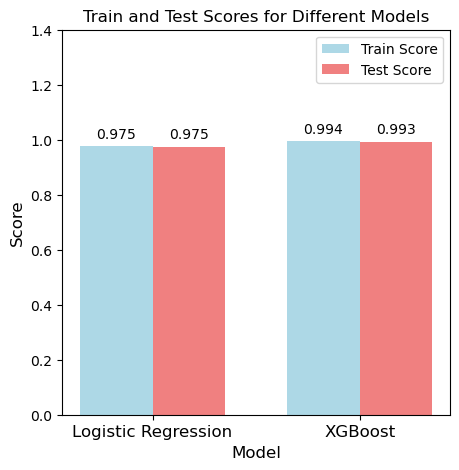

In [432]:
import plotly.graph_objects as go
from sklearn.metrics import accuracy_score
# Train and test scores
log_reg_train_score = lr_model.score(X_train, y_train)
log_reg_test_score = lr_model.score(X_test, y_test)

xgb_train_score = xgb_model.score(X_train, y_train)
xgb_test_score = xgb_model.score(X_test, y_test)

# Create a DataFrame to store the results
df_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'Train Score': [log_reg_train_score, xgb_train_score],
    'Test Score': [log_reg_test_score, xgb_test_score]
})

# Plotting with matplotlib
fig, ax = plt.subplots(figsize=(5, 5))  # Increase the figure size to ensure readability

# Plot the Train and Test scores for each model
bar_width = 0.35  # width of the bars
index = range(len(df_results))  # Model index positions

# Plot bars for Train Score and Test Score
train_bars = ax.bar(index, df_results['Train Score'], bar_width, label='Train Score', color='lightblue')
test_bars = ax.bar([i + bar_width for i in index], df_results['Test Score'], bar_width, label='Test Score', color='lightcoral')

# Add labels, title, and customize axis
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Train and Test Scores for Different Models', fontsize=12)
ax.set_xticks([i + bar_width / 2 for i in index])  # Position the x-axis ticks in the middle of the bars
ax.set_xticklabels(df_results['Model'], fontsize=12)
ax.legend()
ax.set_ylim(0, 1.4)

# Add value labels on top of the bars
for bar in train_bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval + 0.02, round(yval, 3), ha='center', va='bottom', fontsize=10)

for bar in test_bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval + 0.02, round(yval, 3), ha='center', va='bottom', fontsize=10)

# Show plot
plt.show()

In [438]:
def plotting_confusion_matrix(y_test, y_predict_lr, y_predict_xgb):
    
    # Confusion Matrix for both models
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    
    # Logistic Regression Confusion Matrix
    cm_log = confusion_matrix(y_test, y_pred_lr)
    sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['No Default', 'Default'], yticklabels=['No Default', 'Default'], ax=ax[0])
    ax[0].set_title('Logistic Regression Confusion Matrix')
    ax[0].set_xlabel('Predicted')
    ax[0].set_ylabel('Actual')
    
    # XGBoost Confusion Matrix
    cm_xgb = confusion_matrix(y_test, y_pred_xgb)
    sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['No Default', 'Default'], yticklabels=['No Default', 'Default'], ax=ax[1])
    ax[1].set_title('XGBoost Confusion Matrix')
    ax[1].set_xlabel('Predicted')
    ax[1].set_ylabel('Actual')
    
    plt.tight_layout()
    plt.show()

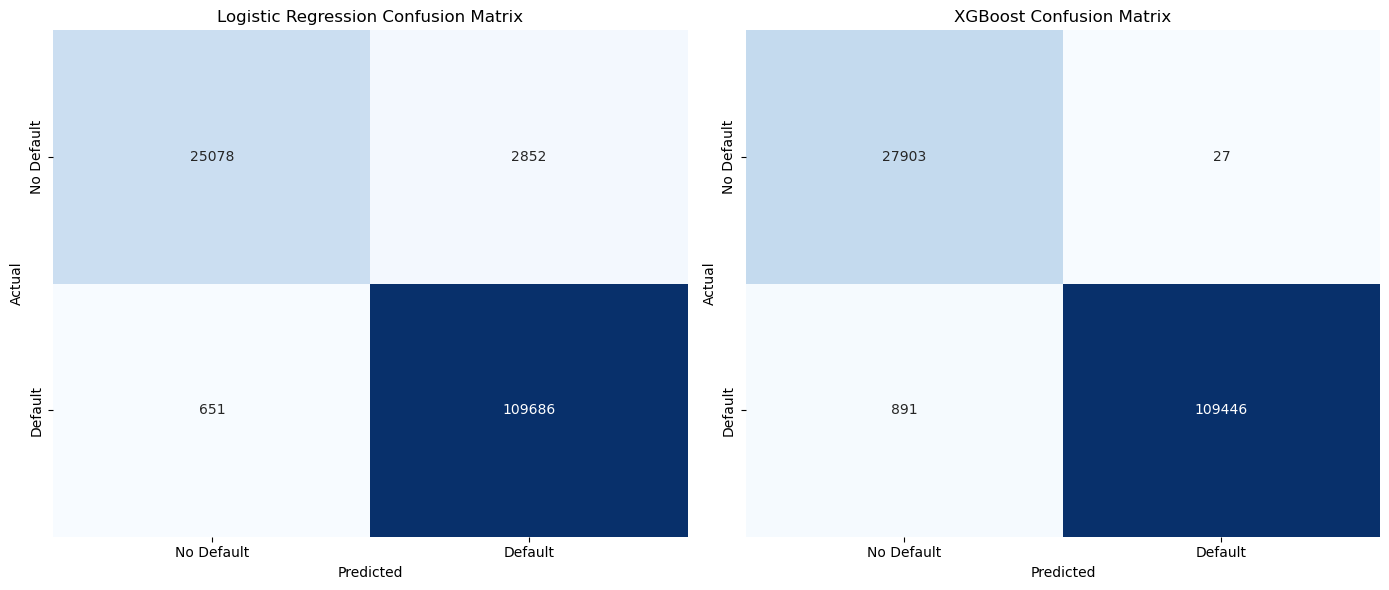

In [440]:
plotting_confusion_matrix(y_test, y_pred_lr, y_pred_xgb)